In [356]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from turtle import color
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

# **| Trabajo sobre Grecia**

In [357]:
resultados = {}

# Entire home/apt

In [358]:
#Cargar desde un archivo .csv
Grecia_EH = pd.read_csv('room_type_Grecia/Entire_homeapt_Grecia.csv')

Grecia_EH.head()

,last_scraped,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,2024-09-23,city scrape,"3 bedrooms, 2 bathrooms, 2nd floor with elevator",The apartment is 3-bedroom apartment with 2-ba...,Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,340,53.0,0.0,4.87,4.89,4.85,4.91,4.58,4.75,0.33
1,2024-09-23,city scrape,Athens Quality Apartments - Deluxe Apartment,Athens Quality Apartments - Deluxe apartment i...,Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,350,82.0,0.0,4.83,4.85,4.85,4.90,4.80,4.75,0.56
2,2024-09-23,city scrape,Athens Quality Apartments - Studio,The Studio is an <br />-excellent located <br ...,Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,341,107.0,0.0,4.85,4.92,4.93,4.97,4.79,4.78,0.73
3,2024-09-23,city scrape,"AQA-No2 1-bedroom, smart tv, fiber connection,","AQA No2 is 1-bedroom apartment (47m2), on the ...",Ampelokipi district is nice multinational and ...,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,350,36.0,0.0,4.83,4.97,4.91,4.89,4.82,4.82,0.21
4,2024-09-23,city scrape,"AQA-No7, Great mattress, high speed internet",THE MATTRESS - KING KOIL - Camden Luxury 160x2...,No disponible,Emmanouil,2009-09-08,"Athens, Greece",Athens Quality Apartments is a company started...,within an hour,...,358,25.0,0.0,4.84,4.88,4.96,4.96,4.75,4.71,0.17


In [359]:
Grecia_EH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13001 entries, 0 to 13000
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   last_scraped                 13001 non-null  object 
 1   source                       13001 non-null  object 
 2   name                         13001 non-null  object 
 3   description                  13001 non-null  object 
 4   neighborhood_overview        13001 non-null  object 
 5   host_name                    13001 non-null  object 
 6   host_since                   13001 non-null  object 
 7   host_location                13001 non-null  object 
 8   host_about                   13001 non-null  object 
 9   host_response_time           13001 non-null  object 
 10  host_is_superhost            13001 non-null  object 
 11  host_verifications           13001 non-null  object 
 12  host_identity_verified       13001 non-null  object 
 13  neighbourhood_cl

In [360]:
# Variables binarias: Convertir "yes" -> 1, "no" -> 0
binary_vars = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
for var in binary_vars:
    Grecia_EH[var] = Grecia_EH[var].map({'t': 1, 'f': 0})  # 't' (true) y 'f' (false) en el dataset

In [361]:
# Convertir "property_type" en variables numéricas label encoding
le = LabelEncoder()
Grecia_EH["property_type_encoded"] = le.fit_transform(Grecia_EH["property_type"])

In [ ]:
# Supongamos que 1 Euro = 21.94 Pesos Mexicanos
conversion_rate = 21.94

# Convertir la columna 'price' de Euros a Pesos Mexicanos
Grecia_EH['price'] = Grecia_EH['price'] * conversion_rate


In [362]:
comparaciones = [
    ("price", "host_acceptance_rate"),
    ("price", "host_is_superhost"),
    ("accommodates", "bathrooms"),
    ("price", "review_scores_cleanliness"),
    ("price", "host_identity_verified"),
    ("price", "instant_bookable"),
    ("price", "property_type_encoded")
]

In [363]:
#eliminamos la columna tipo string
df = Grecia_EH.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13001 entries, 0 to 13000
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            13001 non-null  int64  
 1   host_identity_verified       13001 non-null  int64  
 2   instant_bookable             13001 non-null  int64  
 3   id                           13001 non-null  int64  
 4   host_response_rate           13001 non-null  float64
 5   host_acceptance_rate         13001 non-null  float64
 6   host_listings_count          13001 non-null  float64
 7   host_total_listings_count    13001 non-null  float64
 8   latitude                     13001 non-null  float64
 9   longitude                    13001 non-null  float64
 10  accommodates                 13001 non-null  float64
 11  bathrooms                    13001 non-null  float64
 12  bedrooms                     13001 non-null  float64
 13  beds            

In [364]:
#Encontramos todas las correlaciones entre las variables
corr_Factors = df.corr()
corr_Factors

,host_is_superhost,host_identity_verified,instant_bookable,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,...,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,property_type_encoded
host_is_superhost,1.000000,0.057729,-0.032886,-0.098134,0.071427,0.086757,-0.131178,-0.116514,-0.072130,-0.059512,...,0.207057,0.235272,0.243528,0.212442,0.229044,0.155236,0.109254,0.209557,0.248548,-0.066472
host_identity_verified,0.057729,1.000000,-0.019517,-0.044293,0.115897,-0.004989,0.034535,0.036375,0.024085,-0.013483,...,0.039977,0.050004,-0.006626,-0.003788,-0.009355,0.002895,-0.007335,0.005314,0.051985,-0.015916
instant_bookable,-0.032886,-0.019517,1.000000,0.116473,-0.018772,0.252629,0.242819,0.230914,-0.088087,-0.028217,...,-0.012868,0.010654,-0.121186,-0.109887,-0.100046,-0.123774,-0.038554,-0.116716,0.054180,0.096861
id,-0.098134,-0.044293,0.116473,1.000000,-0.042318,-0.002673,0.040494,0.042144,0.046177,0.014037,...,-0.515960,-0.055175,0.034988,0.018222,0.041302,0.005709,-0.049229,0.009074,-0.047014,0.035233
host_response_rate,0.071427,0.115897,-0.018772,-0.042318,1.000000,0.068583,-0.002355,-0.012029,-0.025762,-0.032503,...,0.065728,0.078196,0.076752,0.071142,0.071202,0.101209,0.039492,0.070176,0.078684,-0.028261
host_acceptance_rate,0.086757,-0.004989,0.252629,-0.002673,0.068583,1.000000,0.092543,0.092186,-0.068374,-0.053705,...,0.098331,0.116560,-0.017438,-0.010629,0.008954,-0.010175,-0.006175,-0.010806,0.139522,0.001499
host_listings_count,-0.131178,0.034535,0.242819,0.040494,-0.002355,0.092543,1.000000,0.922335,-0.072294,-0.027566,...,-0.037878,-0.019795,-0.142372,-0.108554,-0.104383,-0.149189,-0.048941,-0.141909,-0.022199,0.120716
host_total_listings_count,-0.116514,0.036375,0.230914,0.042144,-0.012029,0.092186,0.922335,1.000000,-0.074785,-0.029173,...,-0.016322,-0.002154,-0.136518,-0.105964,-0.103009,-0.140180,-0.043511,-0.134048,0.005130,0.106897
latitude,-0.072130,0.024085,-0.088087,0.046177,-0.025762,-0.068374,-0.072294,-0.074785,1.000000,0.146110,...,-0.100791,-0.104893,-0.066959,-0.053861,-0.051275,-0.027002,-0.331898,-0.068324,-0.122744,-0.000015
longitude,-0.059512,-0.013483,-0.028217,0.014037,-0.032503,-0.053705,-0.027566,-0.029173,0.146110,1.000000,...,-0.092405,-0.102862,0.010347,-0.003826,-0.010196,-0.007787,0.093087,-0.027617,-0.121322,-0.030261


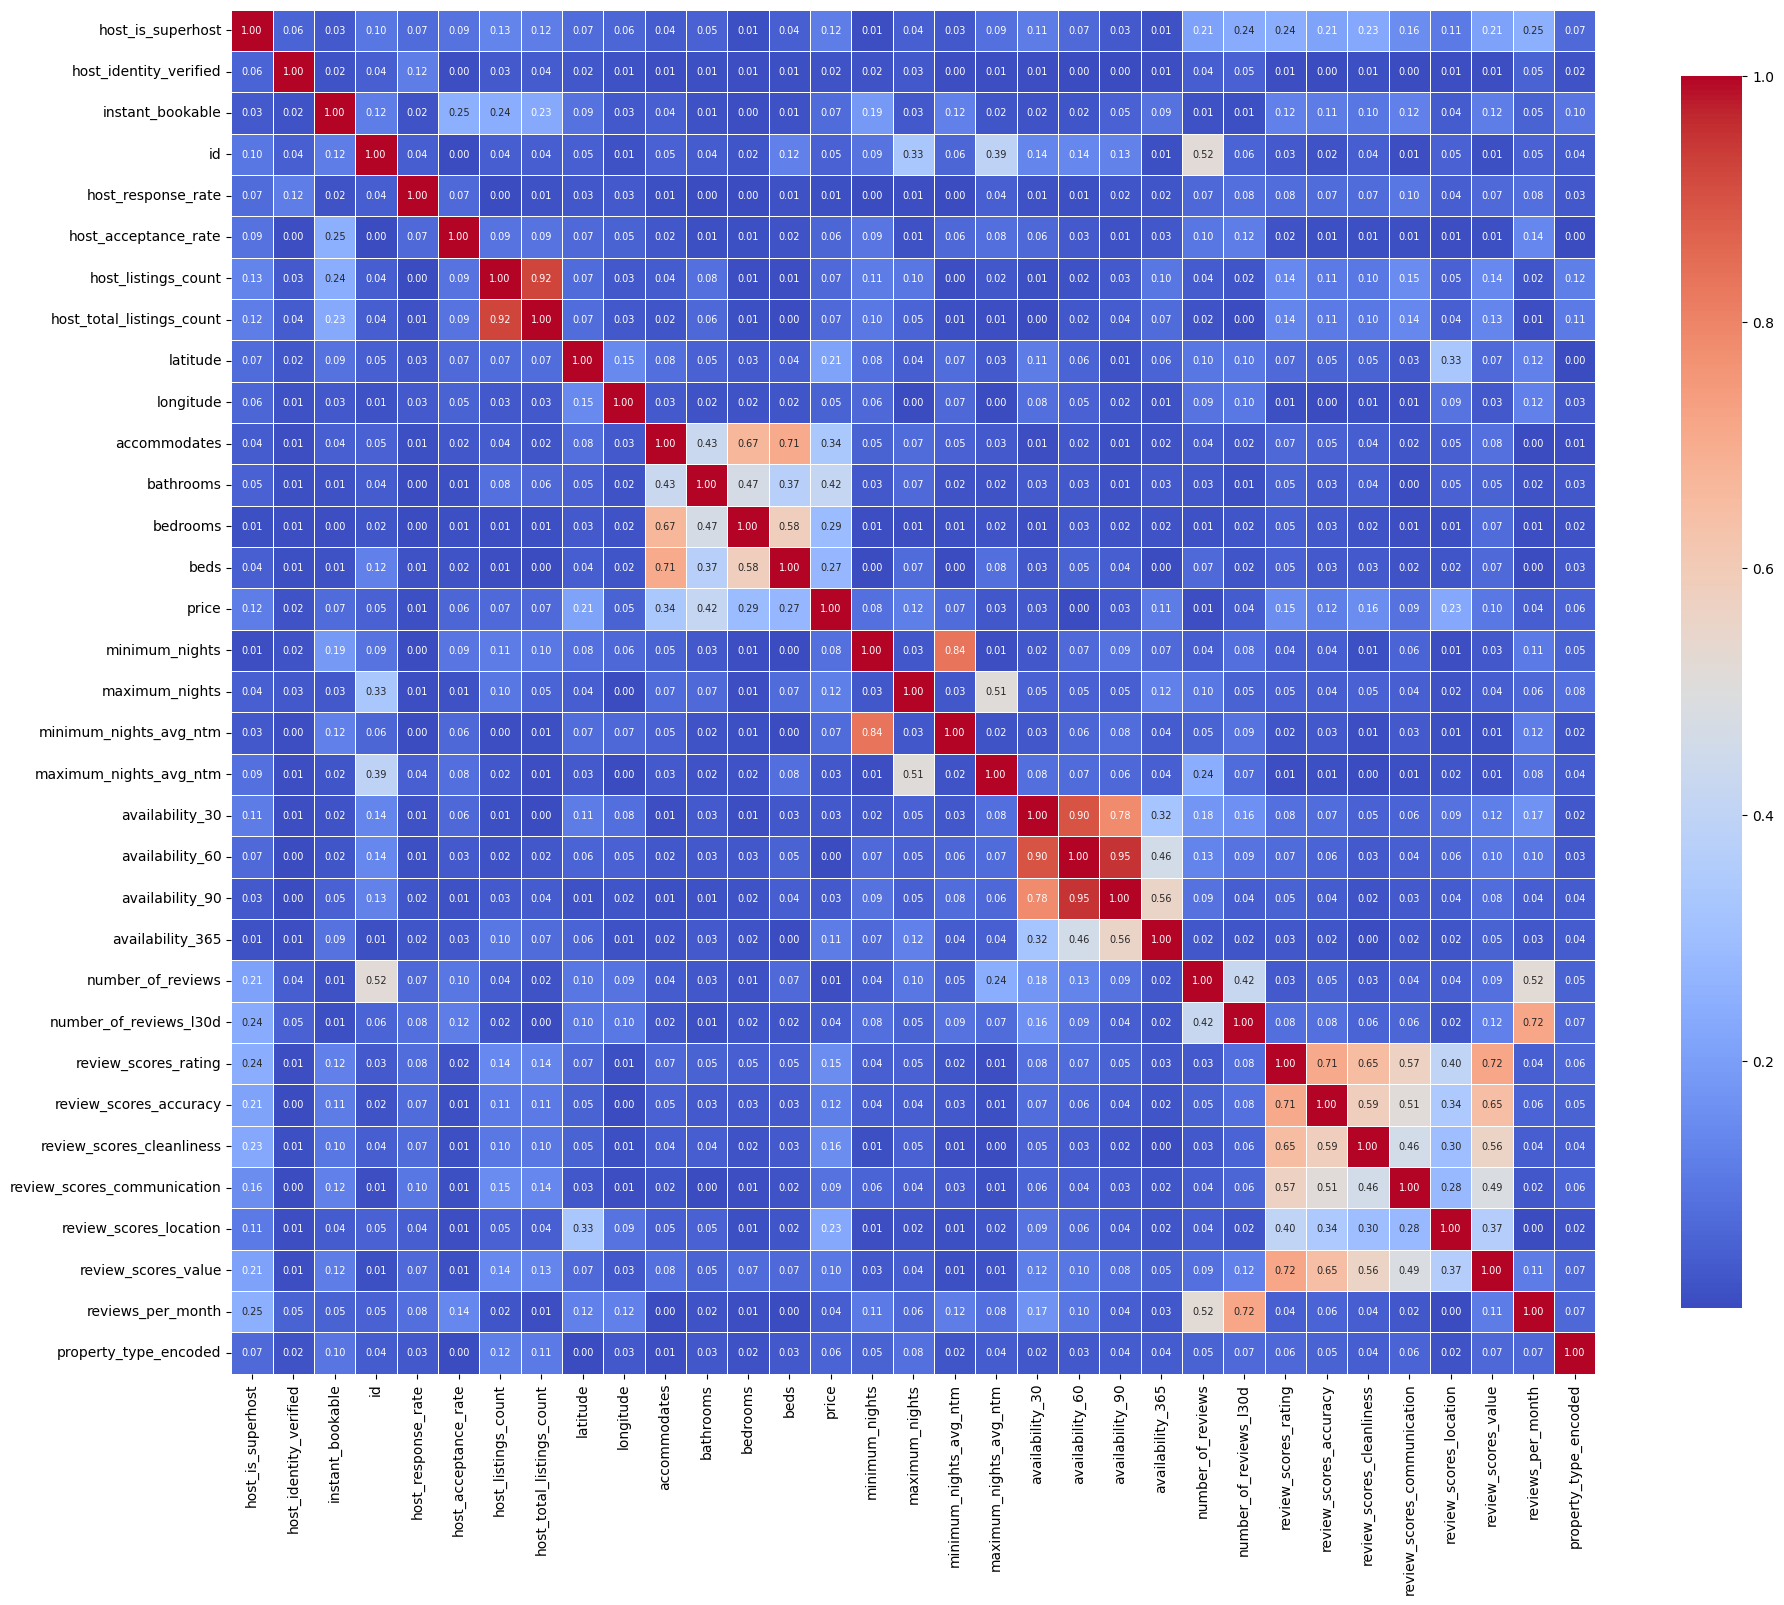

In [365]:
corr_Factors1 = abs(corr_Factors)
# Ajustar el tamaño de la figura
plt.figure(figsize=(22, 20))

# Crear una máscara para la mitad superior (opcional, si quieres ver solo la parte baja)
mask = np.triu(np.ones_like(corr_Factors1, dtype=bool))

# Crear el mapa de calor con mejoras
heat_map = sns.heatmap(
    corr_Factors1, 
    cmap="coolwarm",   # Mejora la diferenciación entre positivos y negativos
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True,       
    annot_kws={"size": 7},  # Reducimos el tamaño de los números internos
    cbar_kws={"shrink": 0.8}  # Hacemos la barra de colores más compacta
)

# Mejoramos la visibilidad de etiquetas
plt.xticks(rotation=90)  # Rota nombres en X para que no se encimen
plt.yticks(rotation=0)   # Mantiene etiquetas en Y horizontales

# Mostrar el gráfico
plt.show()

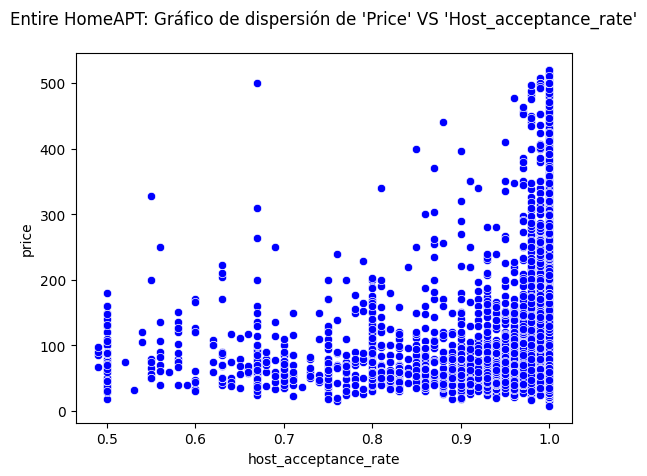

In [366]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(price vs host_acceptance_rate)
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Host_acceptance_rate'\n")
# Mostrar la gráfica
plt.show()

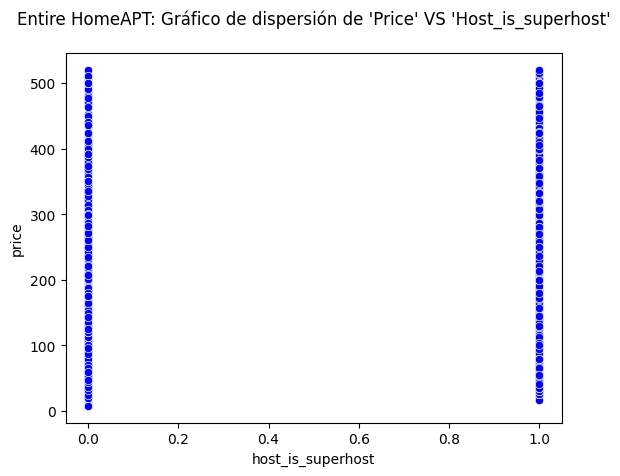

In [367]:
#(price vs host_is_superhost)
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_EH)
# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Host_is_superhost'\n")
# Mostrar la gráfica
plt.show()

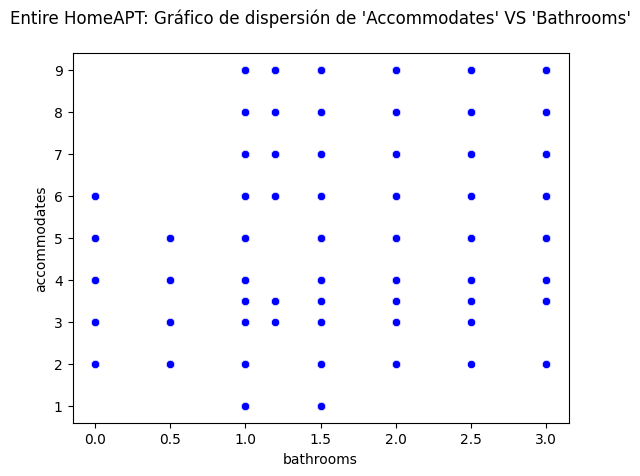

In [368]:
#(accommodates vs bathrooms)
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_EH)
# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Accommodates' VS 'Bathrooms'\n")
# Mostrar la gráfica
plt.show()

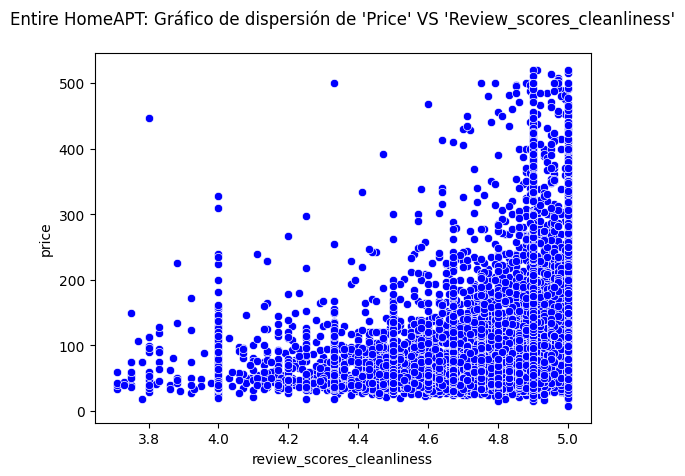

In [369]:
#(price vs review_scores_cleanliness)
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_EH)
# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Review_scores_cleanliness'\n")
# Mostrar la gráfica
plt.show()

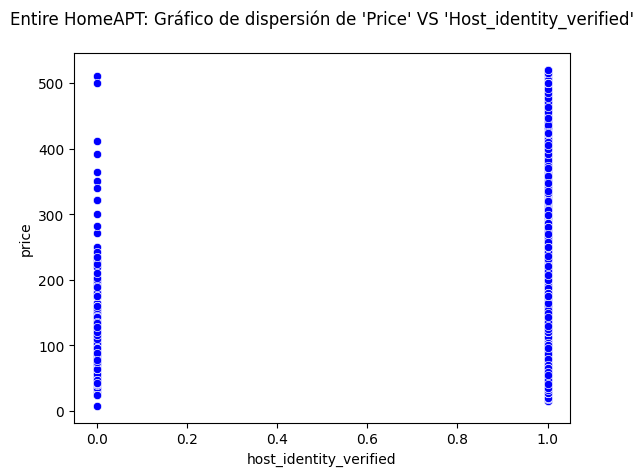

In [370]:
#(price vs host_identity_verified)
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_EH)
# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Host_identity_verified'\n")
# Mostrar la grafica
plt.show()

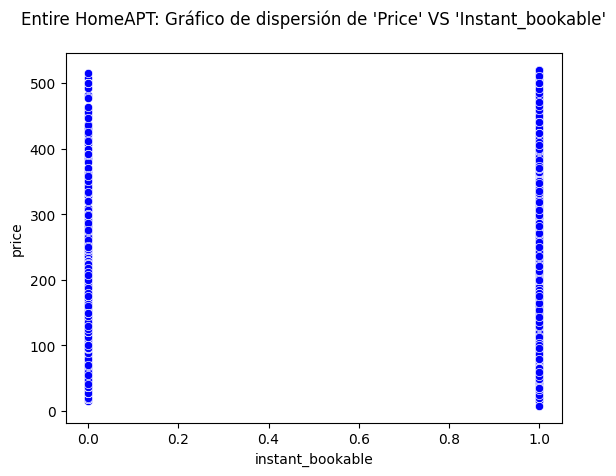

In [371]:
#(price vs instant_bookable)
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_EH)
# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Instant_bookable'\n")
# Mostrar la grafica
plt.show()

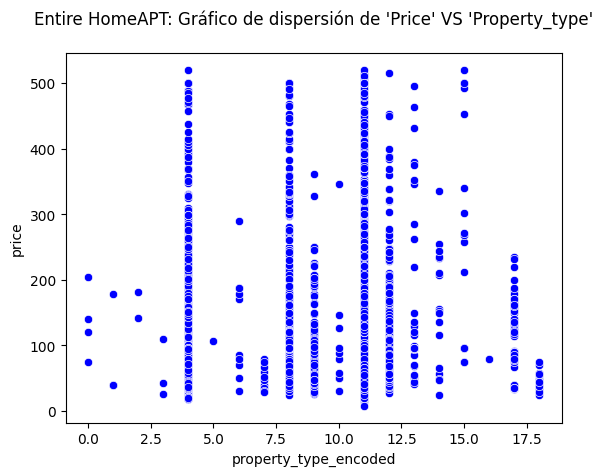

In [372]:
#(price vs property_type)
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_EH)
# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Property_type'\n")
# Mostrar la grafica
plt.show()

**| price vs host_acceptance_rate**

In [373]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['host_acceptance_rate']] 
var_Dep = Grecia_EH['price']

In [374]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [375]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [376]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([63.66456163]),
 'rank_': 1,
 'singular_': array([7.50851209]),
 'intercept_': np.float64(33.224470261889834)}

Modelo Matematico

In [377]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.0038328398163844923

In [378]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['host_acceptance_rate']])
y_pred

array([96.8890319, 96.8890319, 96.8890319, ..., 96.8890319, 89.2492845,
       89.2492845], shape=(13001,))

In [379]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(32, 'Predicciones_price_host_acceptance_rate', y_pred)


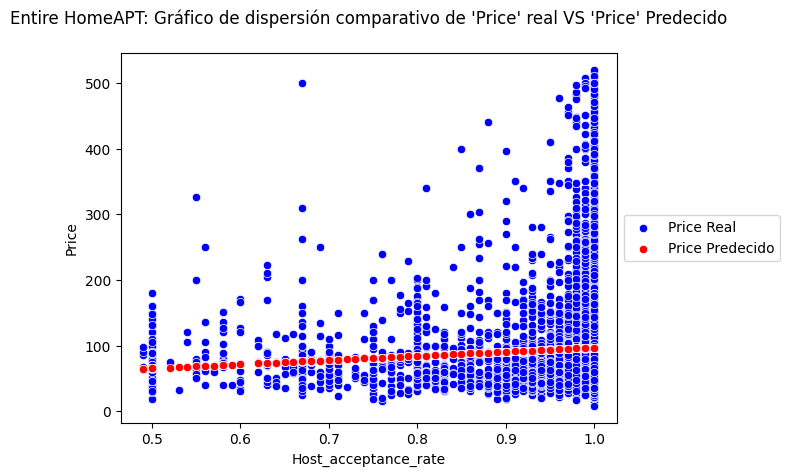

In [380]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_EH)
sns.scatterplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_EH)
#sns.lineplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión comparativo de 'Price' real VS 'Price' Predecido\n")
plt.xlabel("Host_acceptance_rate")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [381]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","price_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.0038328398163844923

In [382]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","price_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.06190993309949941)

**| price vs host_is_superhost**

In [383]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['host_is_superhost']] 
var_Dep = Grecia_EH['price']

In [384]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [385]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [386]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([16.15001115]),
 'rank_': 1,
 'singular_': array([55.96837125]),
 'intercept_': np.float64(88.94081157921921)}

Modelo Matematico

In [387]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.013704032626355445

In [388]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['host_is_superhost']])
y_pred

array([105.09082272, 105.09082272, 105.09082272, ...,  88.94081158,
       105.09082272, 105.09082272], shape=(13001,))

In [389]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(32, 'Predicciones_price_host_is_superhost', y_pred)


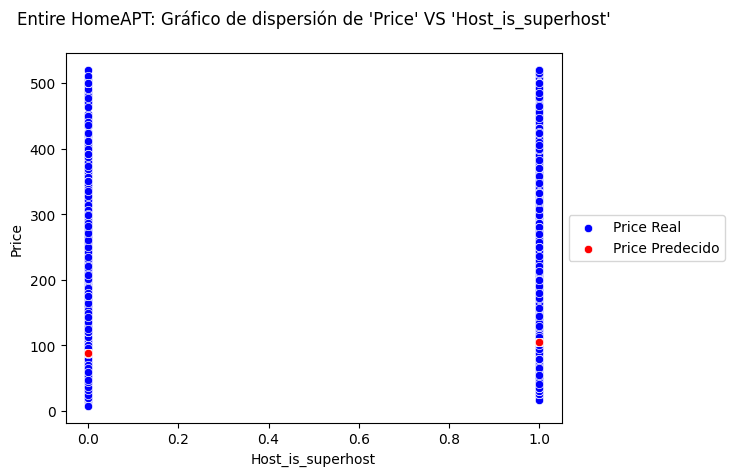

In [390]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_EH)
sns.scatterplot(x='host_is_superhost', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_EH)
#sns.lineplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Host_is_superhost'\n")
plt.xlabel("Host_is_superhost")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [391]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","price_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.013704032626355445

In [392]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","price_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.11706422436575337)

**| accommodates vs bathrooms**

In [393]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['bathrooms']] 
var_Dep = Grecia_EH['accommodates']

In [394]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [395]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [396]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.6948482]),
 'rank_': 1,
 'singular_': array([43.89470798]),
 'intercept_': np.float64(1.6924475028297)}

Modelo Matematico

In [397]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.18644204258501607

In [398]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['bathrooms']])
y_pred

array([5.08214391, 3.38729571, 3.38729571, ..., 3.38729571, 3.38729571,
       3.38729571], shape=(13001,))

In [399]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(29, 'Predicciones_bathrooms_accommodates', y_pred)


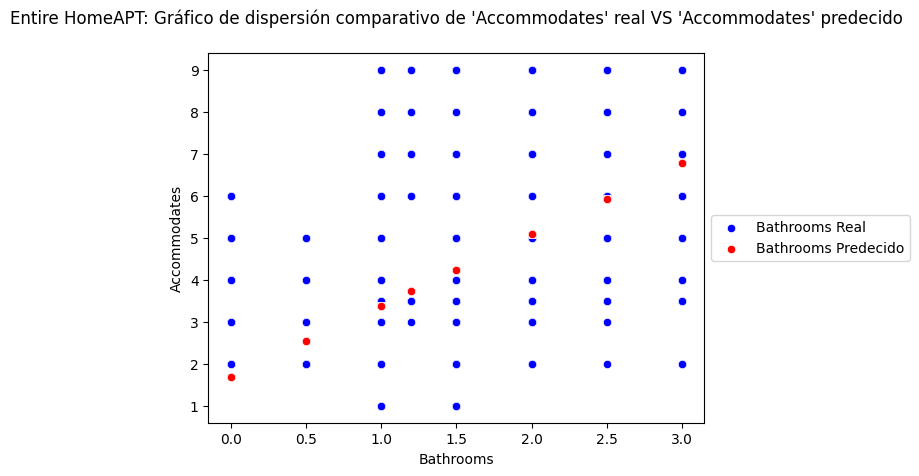

In [400]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_EH)
sns.scatterplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_EH)
#sns.lineplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión comparativo de 'Accommodates' real VS 'Accommodates' predecido\n")
plt.xlabel("Bathrooms")
plt.ylabel("Accommodates")

# Agregar la leyenda manualmente
plt.legend(labels=["Bathrooms Real", "Bathrooms Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [401]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","bathrooms_accommodates","determinacion")] = coef_Deter
coef_Deter

0.18644204258501607

In [402]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","bathrooms_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.4317893497818306)

**| price vs review_scores_cleanliness**

In [403]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['review_scores_cleanliness']] 
var_Dep = Grecia_EH['price']

In [404]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [405]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [406]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([49.29586127]),
 'rank_': 1,
 'singular_': array([24.34652488]),
 'intercept_': np.float64(-142.42716852514664)}

Modelo Matematico

In [407]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.024160853545163397

In [408]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['review_scores_cleanliness']])
y_pred

array([ 96.65775863,  96.65775863, 100.60142753, ...,  99.12255169,
        99.12255169,  99.12255169], shape=(13001,))

In [409]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(32, 'Predicciones_price_review_scores_cleanliness', y_pred)


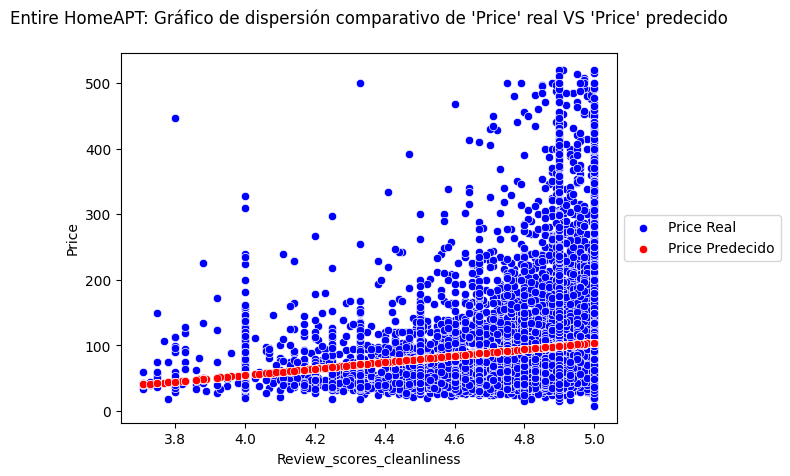

In [410]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_EH)
sns.scatterplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_EH)
#sns.lineplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión comparativo de 'Price' real VS 'Price' predecido\n")
plt.xlabel("Review_scores_cleanliness")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [411]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","price_review_scores_cleanliness","determinacion")] = coef_Deter
coef_Deter

0.024160853545163397

In [412]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","price_review_scores_cleanliness","correlacion")] = coef_Correl
coef_Correl

np.float64(0.15543761946569884)

**| price vs host_identity_verified**

In [413]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['host_identity_verified']] 
var_Dep = Grecia_EH['price']

In [414]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [415]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [416]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_identity_verified'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-7.95954367]),
 'rank_': 1,
 'singular_': array([15.59709226]),
 'intercept_': np.float64(103.28629032258087)}

Modelo Matematico

In [417]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.0002585121838258875

In [418]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['host_identity_verified']])
y_pred

array([95.32674665, 95.32674665, 95.32674665, ..., 95.32674665,
       95.32674665, 95.32674665], shape=(13001,))

In [419]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(32, 'Predicciones_price_host_identity_verified', y_pred)


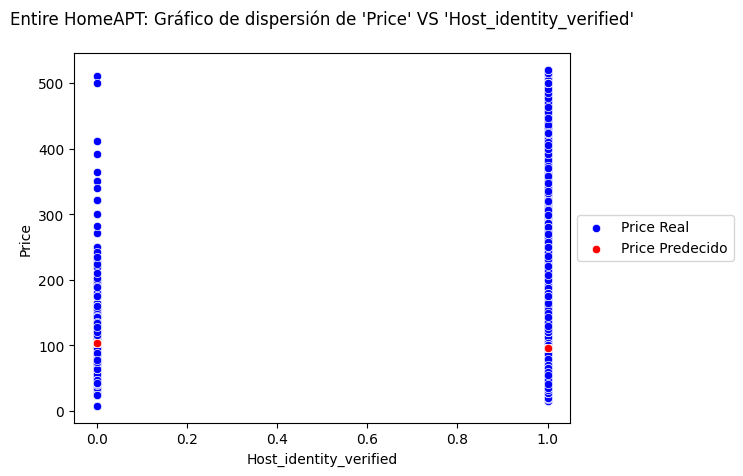

In [420]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_EH)
sns.scatterplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_EH)
#sns.lineplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Host_identity_verified'\n")
plt.xlabel("Host_identity_verified")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [421]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","price_host_identity_verified","determinacion")] = coef_Deter
coef_Deter

0.0002585121838258875

In [422]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","price_host_identity_verified","correlacion")] = coef_Correl
coef_Correl

np.float64(0.016078314085310297)

**| price vs instant_bookable**

In [423]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['instant_bookable']] 
var_Dep = Grecia_EH['price']

In [424]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [425]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [426]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([10.10289798]),
 'rank_': 1,
 'singular_': array([53.86813403]),
 'intercept_': np.float64(88.77310155535224)}

Modelo Matematico

In [427]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.004967903978498223

In [428]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['instant_bookable']])
y_pred

array([98.87599954, 98.87599954, 98.87599954, ..., 98.87599954,
       88.77310156, 88.77310156], shape=(13001,))

In [429]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(32, 'Predicciones_price_instant_bookable', y_pred)


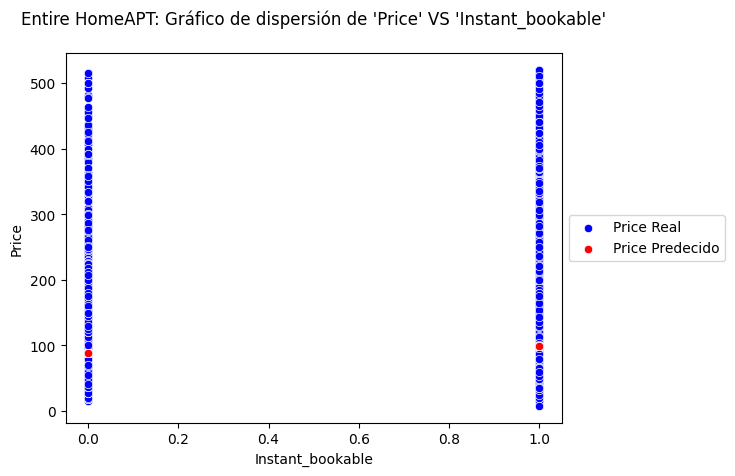

In [430]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_EH)
sns.scatterplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_EH)
#sns.lineplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión de 'Price' VS 'Instant_bookable'\n")
plt.xlabel("Instant_bookable")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [431]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","price_instant_bookable","determinacion")] = coef_Deter
coef_Deter

0.004967903978498223

In [432]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","price_instant_bookable","correlacion")] = coef_Correl
coef_Correl

np.float64(0.07048335958577899)

**| price vs property_type**

In [433]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_EH[['property_type_encoded']] 
var_Dep = Grecia_EH['price']

In [434]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [435]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [436]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type_encoded'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.24151087]),
 'rank_': 1,
 'singular_': array([345.23581665]),
 'intercept_': np.float64(83.87296821783477)}

Modelo Matematico

In [437]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.003081414597254306

In [438]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_EH[['property_type_encoded']])
y_pred

array([88.83901169, 97.52958775, 97.52958775, ..., 97.52958775,
       97.52958775, 97.52958775], shape=(13001,))

In [439]:
#Insertamos la columna de predicciones en el dataframe
Grecia_EH.insert(32, 'Predicciones_price_property_type', y_pred)


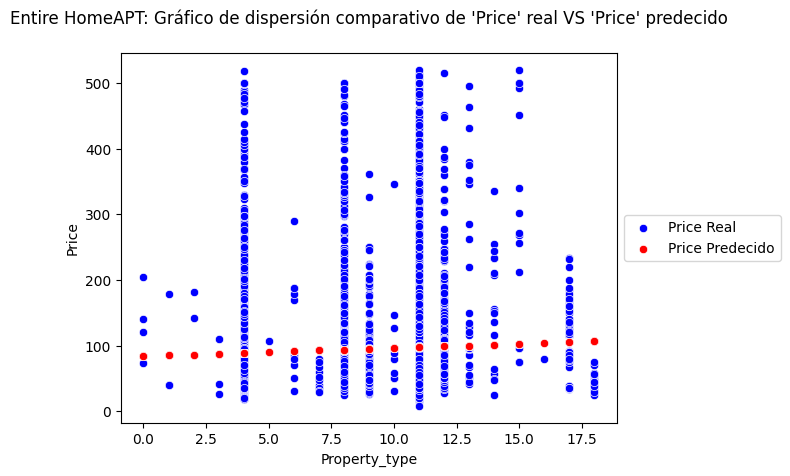

In [440]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_EH)
sns.scatterplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_EH)
#sns.lineplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_EH)

# Configurar el título, etiquetas y leyenda
plt.title("Entire HomeAPT: Gráfico de dispersión comparativo de 'Price' real VS 'Price' predecido\n")
plt.xlabel("Property_type")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [441]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Entire_homeapt","price_property_type","determinacion")] = coef_Deter
coef_Deter

0.003081414597254306

In [442]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Entire_homeapt","price_property_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.05551049087563815)

In [443]:
Grecia_EH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13001 entries, 0 to 13000
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   last_scraped                                  13001 non-null  object 
 1   source                                        13001 non-null  object 
 2   name                                          13001 non-null  object 
 3   description                                   13001 non-null  object 
 4   neighborhood_overview                         13001 non-null  object 
 5   host_name                                     13001 non-null  object 
 6   host_since                                    13001 non-null  object 
 7   host_location                                 13001 non-null  object 
 8   host_about                                    13001 non-null  object 
 9   host_response_time                            13001 non-null 

# Hotel Room

In [444]:
#Cargar desde un archivo .csv
Grecia_HR = pd.read_csv('room_type_Grecia/Hotel_room_Grecia.csv')

Grecia_HR.head()

,last_scraped,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,2024-09-23,previous scrape,Standard Double Room with private shower & Bal...,"My place is close to restaurants and dining, p...",No disponible,Konstantinos,2016-01-10,"Athens, Greece",No disponible,within an hour,...,320,1.0,0.0,4.00,5.00,5.00,5.00,5.00,5.00,0.01
1,2024-09-23,city scrape,Triple Room with private shower & Balcony,"My place is close to restaurants and dining, p...",No disponible,Konstantinos,2016-01-10,"Athens, Greece",No disponible,within an hour,...,328,1.0,0.0,5.00,5.00,5.00,5.00,5.00,5.00,0.03
2,2024-09-23,city scrape,Exceptional Penthouse close to Acropolis by GHH,This exceptional Penthouse close to the Acropo...,A formerly low-profile neighborhood at the foo...,Golden Home Holidays,2015-10-20,"Athens, Greece","Find your own home in Greece, for holidays or ...",within an hour,...,135,84.0,1.0,4.64,4.73,4.73,4.94,4.95,4.69,1.03
3,2024-09-23,city scrape,"Acropolis Grand Residence, Stunning Views","Located in a 1930’s neoclassical building, dir...",The residence is located at 12 Syggrou avenue ...,Vasileios,2017-01-31,"Athens, Greece",We are Bill & John two young entrepreneurs wit...,within an hour,...,292,184.0,1.0,4.98,4.97,4.97,4.98,4.99,4.95,2.33
4,2024-09-23,city scrape,AcropolisView -Two Bedroom Apt by Meros,The apartment is located at the foothills of A...,Thissio is a traditional neighborhood in downt...,Meros,2015-05-06,"Athens, Greece","Hi, we are Meros team and we will be your host...",within an hour,...,74,116.0,5.0,4.77,4.84,4.88,4.79,4.92,4.79,1.48


In [445]:
Grecia_HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   last_scraped                 74 non-null     object 
 1   source                       74 non-null     object 
 2   name                         74 non-null     object 
 3   description                  74 non-null     object 
 4   neighborhood_overview        74 non-null     object 
 5   host_name                    74 non-null     object 
 6   host_since                   74 non-null     object 
 7   host_location                74 non-null     object 
 8   host_about                   74 non-null     object 
 9   host_response_time           74 non-null     object 
 10  host_is_superhost            74 non-null     object 
 11  host_verifications           74 non-null     object 
 12  host_identity_verified       74 non-null     object 
 13  neighbourhood_cleansed

In [446]:
# Variables binarias: Convertir "yes" -> 1, "no" -> 0
binary_vars = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
for var in binary_vars:
    Grecia_HR[var] = Grecia_HR[var].map({'t': 1, 'f': 0})  # 't' (true) y 'f' (false) en el dataset

In [447]:
# Convertir "property_type" en variables numéricas label encoding
le = LabelEncoder()
Grecia_HR["property_type_encoded"] = le.fit_transform(Grecia_HR["property_type"])

In [448]:
comparaciones = [
    ("price", "host_acceptance_rate"),
    ("price", "host_is_superhost"),
    ("accommodates", "bathrooms"),
    ("price", "review_scores_cleanliness"),
    ("price", "host_identity_verified"),
    ("price", "instant_bookable")
]

In [449]:
#eliminamos la columna tipo string
df = Grecia_HR.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            74 non-null     int64  
 1   host_identity_verified       74 non-null     int64  
 2   instant_bookable             74 non-null     int64  
 3   id                           74 non-null     int64  
 4   host_response_rate           74 non-null     float64
 5   host_acceptance_rate         74 non-null     float64
 6   host_listings_count          74 non-null     float64
 7   host_total_listings_count    74 non-null     float64
 8   latitude                     74 non-null     float64
 9   longitude                    74 non-null     float64
 10  accommodates                 74 non-null     float64
 11  bathrooms                    74 non-null     float64
 12  bedrooms                     74 non-null     float64
 13  beds                  

In [450]:
#Encontramos todas las correlaciones entre las variables
corr_Factors = df.corr()
corr_Factors

,host_is_superhost,host_identity_verified,instant_bookable,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,...,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,property_type_encoded
host_is_superhost,1.000000,NaN,-0.684435,-0.120142,0.103414,0.092089,0.856433,0.779562,-0.191295,-0.099612,...,0.068745,-0.049744,0.061877,-0.013928,0.159061,0.081207,0.153514,0.052065,-0.010089,0.230879
host_identity_verified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instant_bookable,-0.684435,NaN,1.000000,-0.099870,-0.103414,-0.092089,-0.559267,-0.495521,-0.021774,0.110512,...,0.131001,0.122493,-0.093662,-0.010670,-0.180057,-0.102678,-0.089799,-0.045644,0.136332,-0.178309
id,-0.120142,NaN,-0.099870,1.000000,-0.545528,-0.233761,0.029073,0.066169,0.494803,0.407492,...,-0.000927,-0.028403,-0.030388,-0.236055,-0.177404,-0.198209,-0.376703,-0.263767,0.060796,-0.255852
host_response_rate,0.103414,NaN,-0.103414,-0.545528,1.000000,-0.143439,0.094325,0.124268,-0.162045,-0.852533,...,0.198958,0.163445,0.162588,0.204338,0.334603,0.191693,0.373861,0.244660,0.193520,0.665327
host_acceptance_rate,0.092089,NaN,-0.092089,-0.233761,-0.143439,1.000000,0.110124,0.115954,-0.814278,0.193366,...,0.090306,0.085525,-0.078976,0.028754,-0.001400,-0.077965,0.524898,0.114710,0.085128,-0.249837
host_listings_count,0.856433,NaN,-0.559267,0.029073,0.094325,0.110124,1.000000,0.981427,-0.189124,-0.002073,...,0.083533,-0.075770,0.032693,-0.026487,0.203062,-0.010362,0.200901,0.004814,-0.000731,0.147221
host_total_listings_count,0.779562,NaN,-0.495521,0.066169,0.124268,0.115954,0.981427,1.000000,-0.201640,0.004718,...,0.091269,-0.077582,-0.005424,-0.046535,0.195759,-0.049463,0.223353,-0.023633,0.006672,0.136756
latitude,-0.191295,NaN,-0.021774,0.494803,-0.162045,-0.814278,-0.189124,-0.201640,1.000000,0.077731,...,-0.152777,-0.128786,0.045122,-0.097153,-0.085693,0.003699,-0.568559,-0.182670,-0.123671,0.112754
longitude,-0.099612,NaN,0.110512,0.407492,-0.852533,0.193366,-0.002073,0.004718,0.077731,1.000000,...,-0.083454,-0.103134,-0.324689,-0.211496,-0.380460,-0.251585,-0.315980,-0.321258,-0.074195,-0.606460


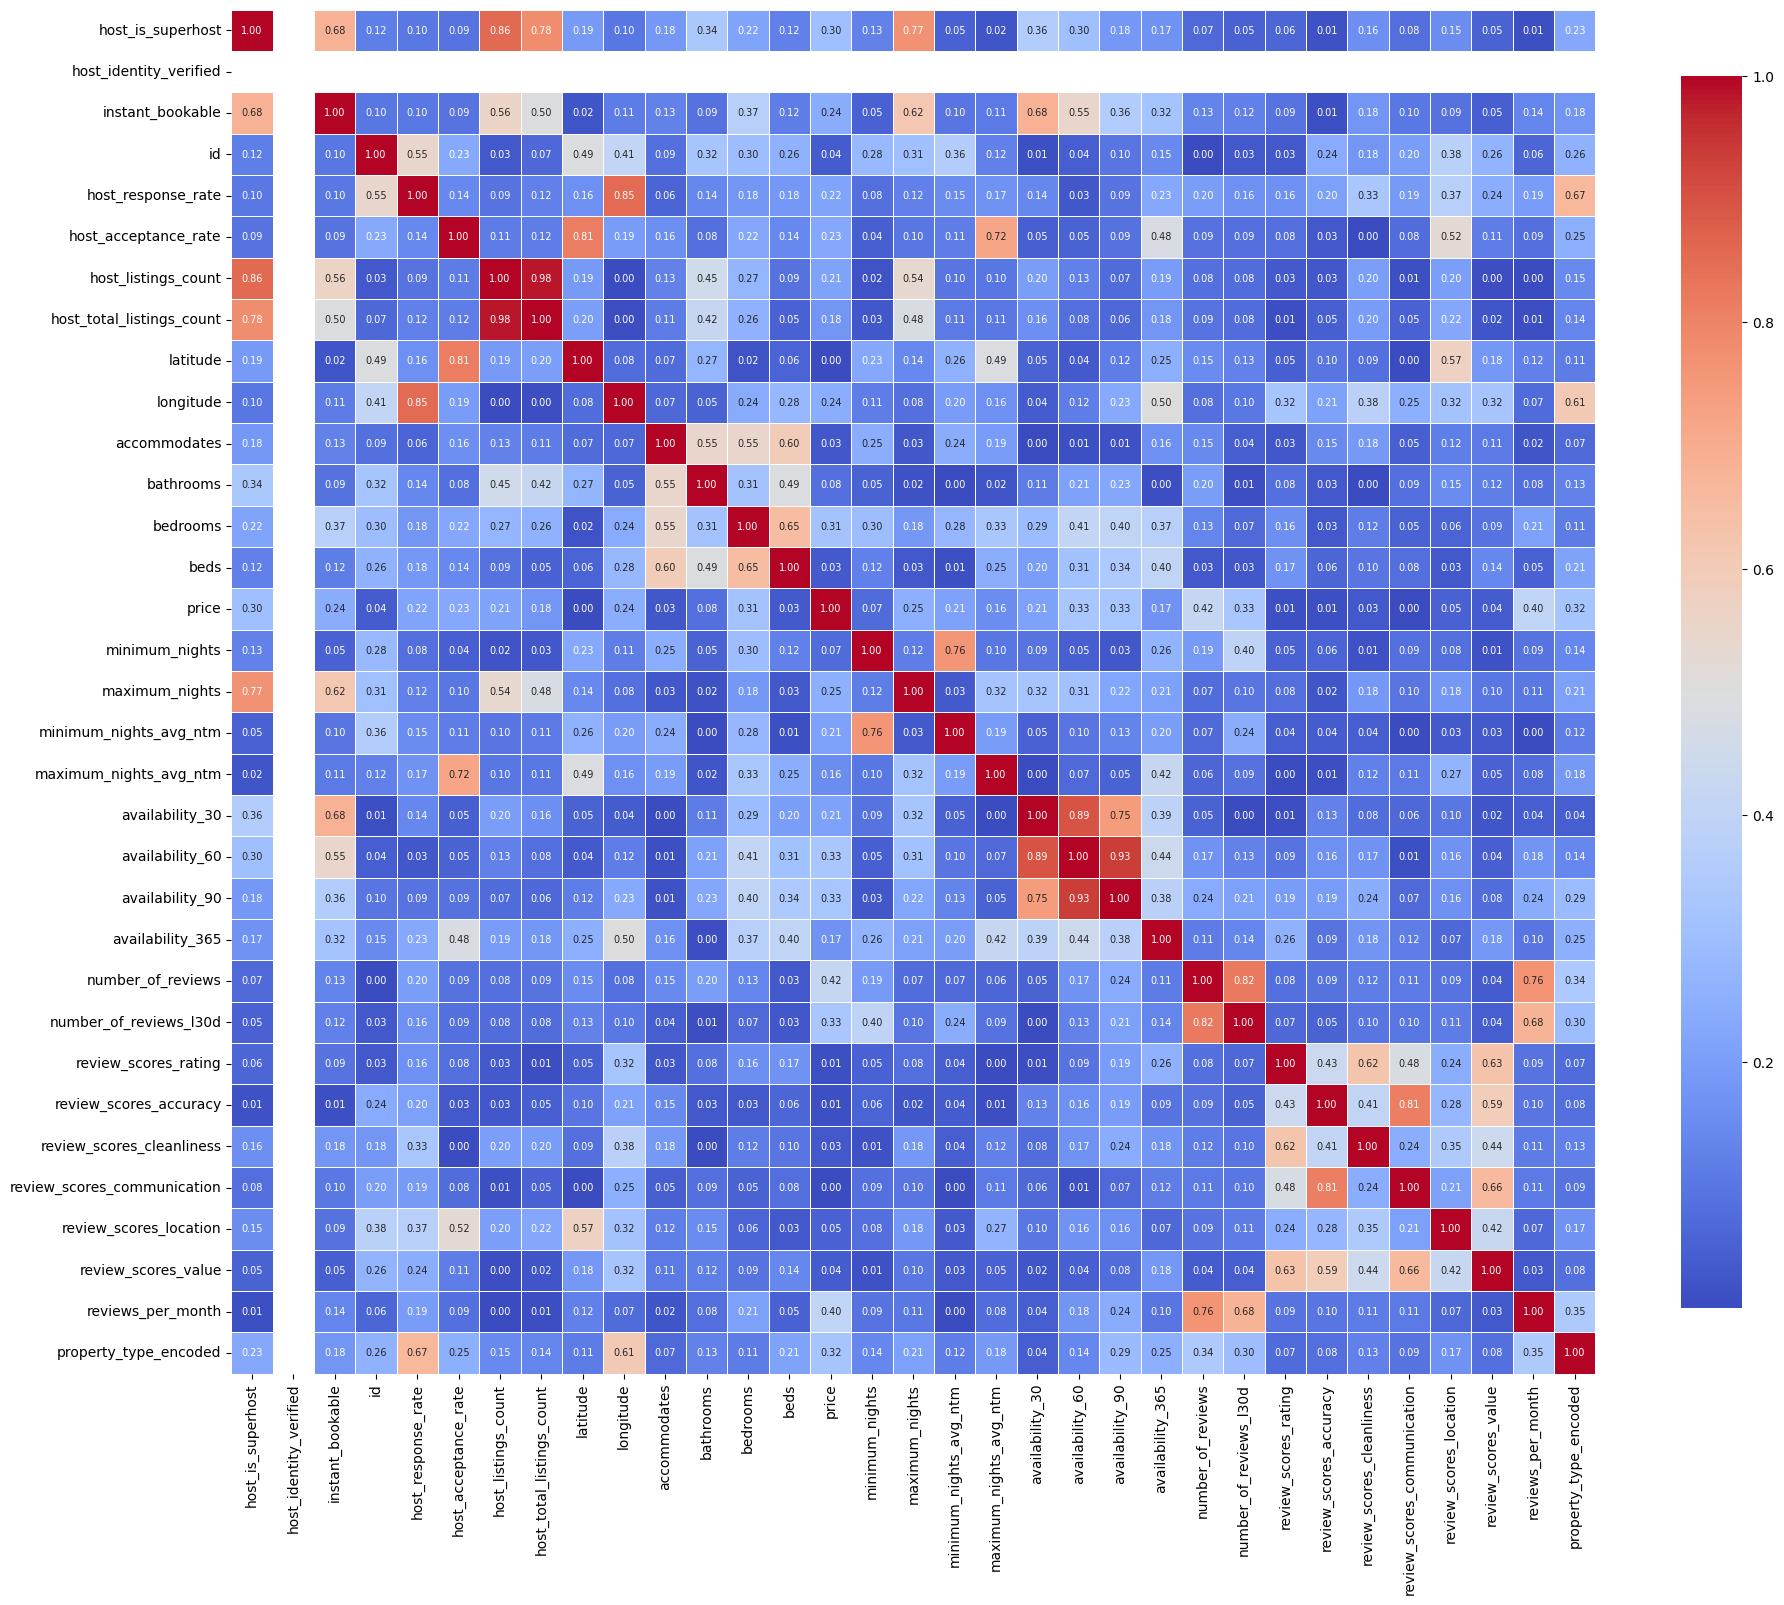

In [451]:
corr_Factors1 = abs(corr_Factors)
# Ajustar el tamaño de la figura
plt.figure(figsize=(22, 20))

# Crear una máscara para la mitad superior (opcional, si quieres ver solo la parte baja)
mask = np.triu(np.ones_like(corr_Factors1, dtype=bool))

# Crear el mapa de calor con mejoras
heat_map = sns.heatmap(
    corr_Factors1, 
    cmap="coolwarm",   # Mejora la diferenciación entre positivos y negativos
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True,       
    annot_kws={"size": 7},  # Reducimos el tamaño de los números internos
    cbar_kws={"shrink": 0.8}  # Hacemos la barra de colores más compacta
)

# Mejoramos la visibilidad de etiquetas
plt.xticks(rotation=90)  # Rota nombres en X para que no se encimen
plt.yticks(rotation=0)   # Mantiene etiquetas en Y horizontales

# Mostrar el gráfico
plt.show()

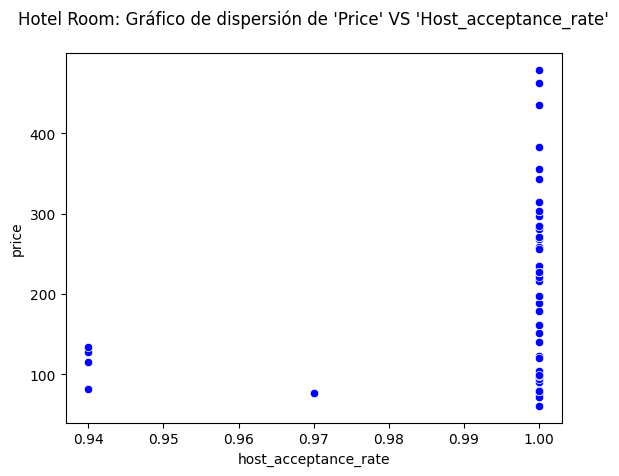

In [452]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(price vs host_acceptance_rate)
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Price' VS 'Host_acceptance_rate'\n")
# Mostrar la gráfica
plt.show()

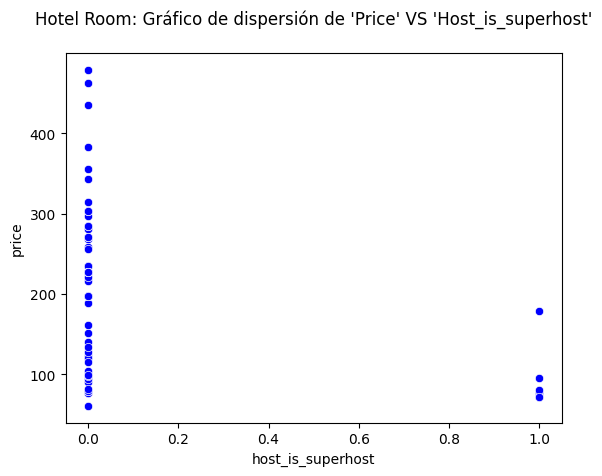

In [453]:
#(price vs host_is_superhost)
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Price' VS 'Host_is_superhost'\n")
# Mostrar la gráfica
plt.show()

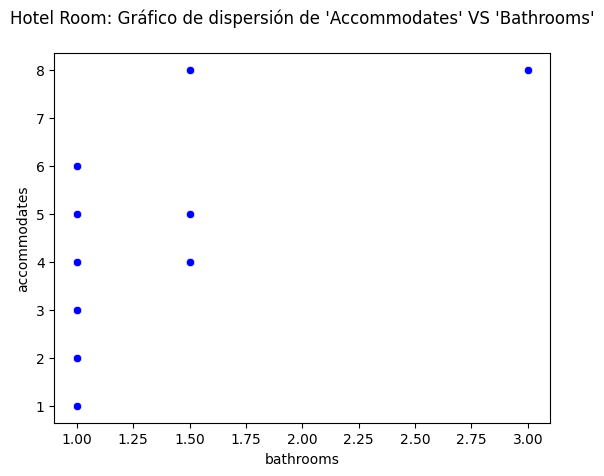

In [454]:
#(accommodates vs bathrooms)
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Accommodates' VS 'Bathrooms'\n")
# Mostrar la gráfica
plt.show()

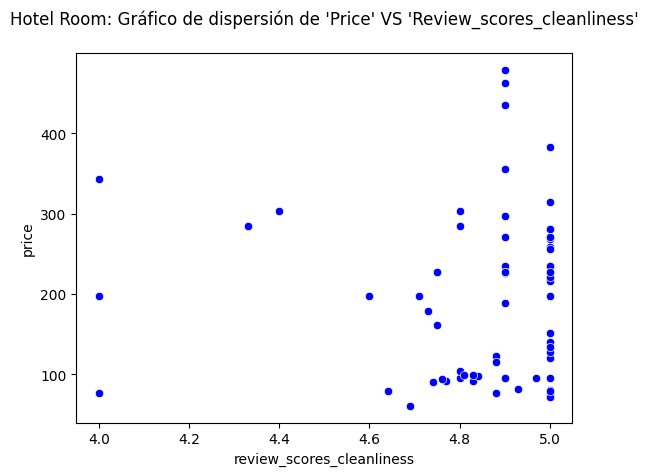

In [455]:
#(price vs review_scores_cleanliness)
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Price' VS 'Review_scores_cleanliness'\n")
# Mostrar la gráfica
plt.show()

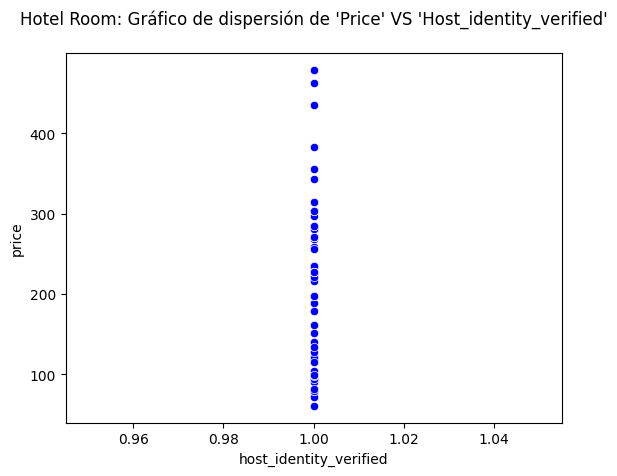

In [456]:
#(price vs host_identity_verified)
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Price' VS 'Host_identity_verified'\n")
# Mostrar la gráfica
plt.show()

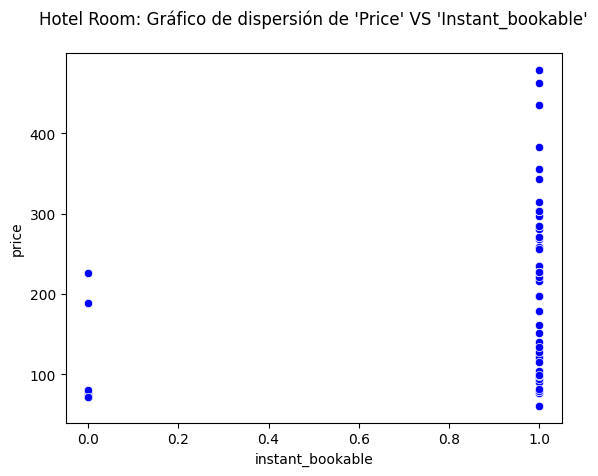

In [457]:
#(price vs instant_bookable)
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Price' VS 'Instant_bookable'\n")
# Mostrar la gráfica
plt.show()

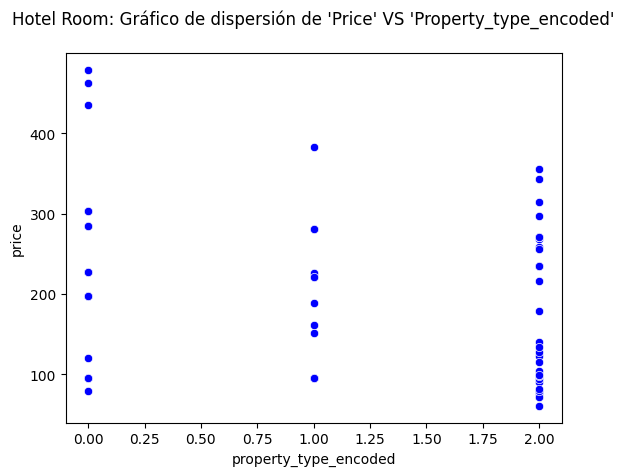

In [458]:
#(price vs property_type)
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_HR)
# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión de 'Price' VS 'Property_type_encoded'\n")
# Mostrar la gráfica
plt.show()

**| price vs host_acceptance_rate**

In [459]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['host_acceptance_rate']]
var_Dep = Grecia_HR['price'] 

In [460]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [461]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [462]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1627.27272727]),
 'rank_': 1,
 'singular_': array([0.12240827]),
 'intercept_': np.float64(-1431.9999999999982)}

Modelo Matematico

In [463]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.05231821321818653

In [464]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['host_acceptance_rate']])
y_pred

array([195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       146.45454545, 146.45454545, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27272727,
       195.27272727, 195.27272727, 195.27272727, 195.27

In [465]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(22, 'Predicciones_price_host_acceptance_rate', y_pred)


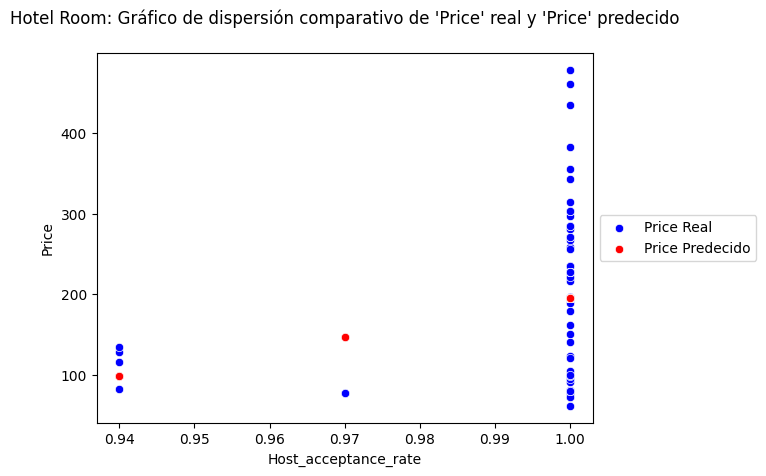

In [466]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_HR)
sns.scatterplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_HR)
#sns.lineplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host_acceptance_rate")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))
# Mostrar la gráfica
plt.show()

In [467]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","price_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.05231821321818653

In [468]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","price_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.2287317494756391)

**| price vs host_is_superhost**

In [469]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['host_is_superhost']]
var_Dep = Grecia_HR['price'] 

In [470]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [471]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [472]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-105.35607676]),
 'rank_': 1,
 'singular_': array([2.51750627]),
 'intercept_': np.float64(198.6417910447761)}

Modelo Matematico

In [473]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.09276219514523298

In [474]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['host_is_superhost']])
y_pred

array([198.64179104, 198.64179104,  93.28571429,  93.28571429,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104,  93.28571429,  93.28571429,
        93.28571429,  93.28571429,  93.28571429, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64179104,
       198.64179104, 198.64179104, 198.64179104, 198.64

In [475]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(10, 'Predicciones_price_host_is_superhost', y_pred)


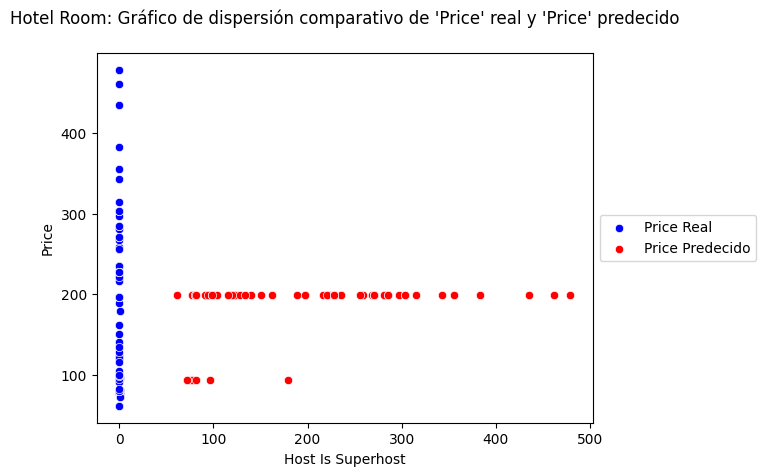

In [476]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_HR)
sns.scatterplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_HR)
#sns.lineplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Is Superhost")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [477]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","price_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.09276219514523298

In [478]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","price_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.30456886765595886)

**| accommodates vs bathrooms**

In [479]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['bathrooms']] 
var_Dep = Grecia_HR['accommodates']

In [480]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [481]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [482]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.74509804]),
 'rank_': 1,
 'singular_': array([2.31110714]),
 'intercept_': np.float64(0.29411764705882426)}

Modelo Matematico

In [483]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.3012167650231615

In [484]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['bathrooms']])
y_pred

array([3.03921569, 3.03921569, 4.41176471, 8.52941176, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 4.41176471,
       4.41176471, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 4.41176471, 4.41176471, 3.03921569, 3.03921569,
       4.41176471, 4.41176471, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569, 3.03921569,
       3.03921569, 3.03921569, 3.03921569, 3.03921569])

In [485]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(29, 'Predicciones_bathrooms_accommodates', y_pred)


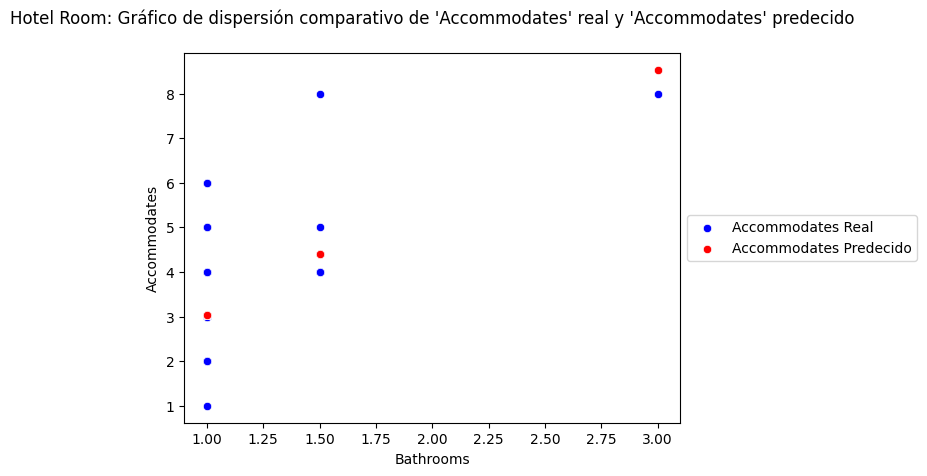

In [486]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_HR)
sns.scatterplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_HR)
#sns.lineplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Accommodates' real y 'Accommodates' predecido\n")
plt.xlabel("Bathrooms")
plt.ylabel("Accommodates")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [487]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","bathrooms_accommodates","determinacion")] = coef_Deter
coef_Deter

0.3012167650231615

In [488]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","bathrooms_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.5488321829331454)

**| price vs review_scores_cleanliness**

In [489]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['review_scores_cleanliness']] 
var_Dep = Grecia_HR['price']

In [490]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [491]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [492]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-14.19512004]),
 'rank_': 1,
 'singular_': array([1.89185452]),
 'intercept_': np.float64(257.5066617734114)}

Modelo Matematico

In [493]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.000950964545163524

In [494]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['review_scores_cleanliness']])
y_pred

array([186.53106159, 186.53106159, 190.363744  , 186.9569152 ,
       188.234476  , 187.9505736 , 187.9505736 , 187.9505736 ,
       186.53106159, 187.9505736 , 187.9505736 , 187.9505736 ,
       187.9505736 , 186.53106159, 200.72618163, 187.9505736 ,
       186.53106159, 186.53106159, 186.53106159, 187.9505736 ,
       186.53106159, 187.9505736 , 186.53106159, 186.53106159,
       186.53106159, 186.53106159, 187.9505736 , 187.9505736 ,
       188.234476  , 200.72618163, 186.53106159, 186.53106159,
       186.53106159, 186.53106159, 186.53106159, 188.944232  ,
       189.7959392 , 190.2217928 , 189.3700856 , 189.9378904 ,
       188.8022808 , 188.944232  , 189.3700856 , 189.2281344 ,
       186.53106159, 186.53106159, 186.53106159, 191.64130481,
       190.93154881, 187.9505736 , 187.9505736 , 186.53106159,
       186.53106159, 190.0798416 , 186.53106159, 186.53106159,
       186.53106159, 190.0798416 , 190.0798416 , 200.72618163,
       189.3700856 , 189.3700856 , 196.04179202, 190.64

In [495]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(32, 'Predicciones_price_review_scores_cleanliness', y_pred)


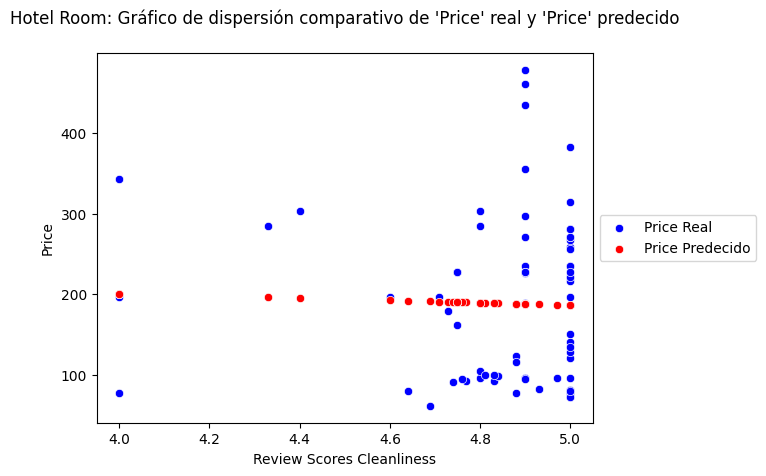

In [496]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_HR)
sns.scatterplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_HR)
#sns.lineplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Review Scores Cleanliness")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [497]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","price_review_scores_cleanliness","determinacion")] = coef_Deter
coef_Deter

0.000950964545163524

In [498]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","price_review_scores_cleanliness","correlacion")] = coef_Correl
coef_Correl

np.float64(0.030837713033938233)

**| price vs host_identity_verified**

In [499]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['host_identity_verified']] 
var_Dep = Grecia_HR['price']

In [500]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [501]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [502]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_identity_verified'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.]),
 'rank_': 0,
 'singular_': array([0.]),
 'intercept_': np.float64(188.67567567567568)}

Modelo Matematico

In [503]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.0

In [504]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['host_identity_verified']])
y_pred

array([188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67567568,
       188.67567568, 188.67567568, 188.67567568, 188.67

In [505]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(32, 'Predicciones_price_host_identity_verified', y_pred)


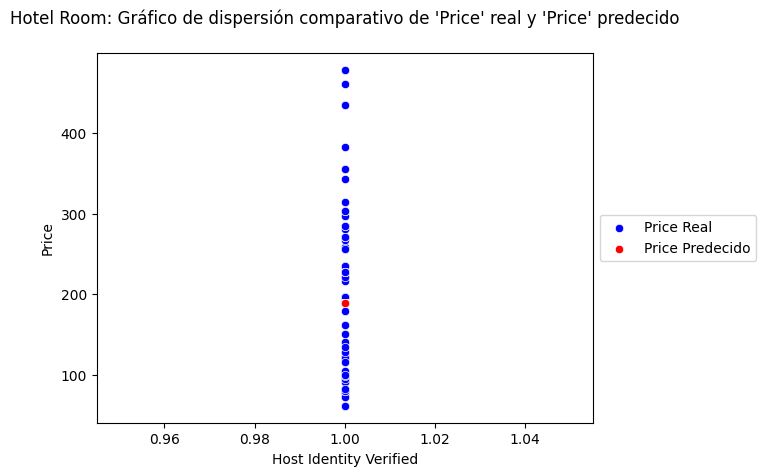

In [506]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_HR)
sns.scatterplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_HR)
#sns.lineplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Identity Verified")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [507]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","price_host_identity_verified","determinacion")] = coef_Deter
coef_Deter

0.0

In [508]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","price_host_identity_verified","correlacion")] = coef_Correl
coef_Correl

np.float64(0.0)

**| price vs instant_bookable**

In [509]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['instant_bookable']] 
var_Dep = Grecia_HR['price']

In [510]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [511]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [512]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([83.26652452]),
 'rank_': 1,
 'singular_': array([2.51750627]),
 'intercept_': np.float64(113.28571428571428)}

Modelo Matematico

In [513]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.057941897445925594

In [514]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['instant_bookable']])
y_pred

array([196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 113.28571429, 113.28571429,
       113.28571429, 113.28571429, 113.28571429, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 113.28571429, 113.28571429, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55223881,
       196.55223881, 196.55223881, 196.55223881, 196.55

In [515]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(32, 'Predicciones_price_instant_bookable', y_pred)


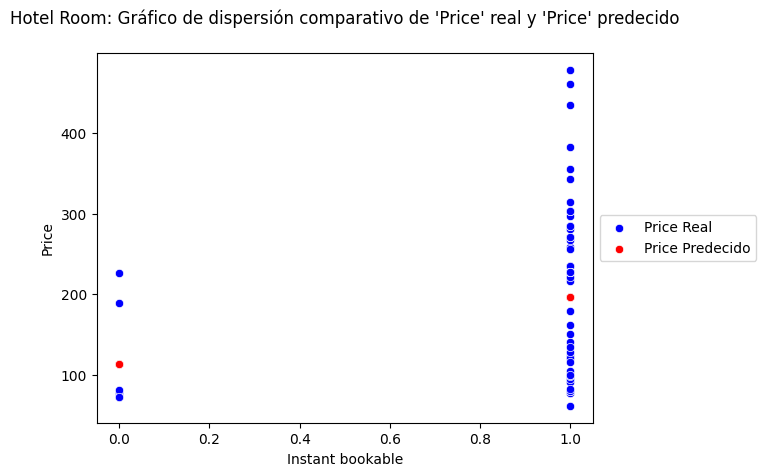

In [516]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_HR)
sns.scatterplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_HR)
#sns.lineplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Instant bookable")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [517]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","price_instant_bookable","determinacion")] = coef_Deter
coef_Deter

0.057941897445925594

In [518]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","price_instant_bookable","correlacion")] = coef_Correl
coef_Correl

np.float64(0.2407112324880698)

**| price vs property_type**

In [519]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_HR[['property_type_encoded']] 
var_Dep = Grecia_HR['price']

In [520]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [521]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [522]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type_encoded'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-37.38508876]),
 'rank_': 1,
 'singular_': array([7.55609652]),
 'intercept_': np.float64(234.64923076923077)}

Modelo Matematico

In [523]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.10522102786750265

In [524]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_HR[['property_type_encoded']])
y_pred

array([197.26414201, 197.26414201, 159.87905325, 197.26414201,
       159.87905325, 197.26414201, 197.26414201, 197.26414201,
       234.64923077, 234.64923077, 234.64923077, 234.64923077,
       234.64923077, 159.87905325, 159.87905325, 159.87905325,
       159.87905325, 159.87905325, 159.87905325, 159.87905325,
       159.87905325, 159.87905325, 159.87905325, 159.87905325,
       159.87905325, 159.87905325, 159.87905325, 234.64923077,
       159.87905325, 159.87905325, 159.87905325, 159.87905325,
       159.87905325, 159.87905325, 159.87905325, 159.87905325,
       159.87905325, 159.87905325, 159.87905325, 159.87905325,
       159.87905325, 159.87905325, 159.87905325, 159.87905325,
       234.64923077, 159.87905325, 234.64923077, 159.87905325,
       159.87905325, 197.26414201, 197.26414201, 197.26414201,
       197.26414201, 197.26414201, 197.26414201, 197.26414201,
       234.64923077, 234.64923077, 234.64923077, 234.64923077,
       234.64923077, 234.64923077, 234.64923077, 234.64

In [525]:
#Insertamos la columna de predicciones en el dataframe
Grecia_HR.insert(32, 'Predicciones_price_property_type', y_pred)


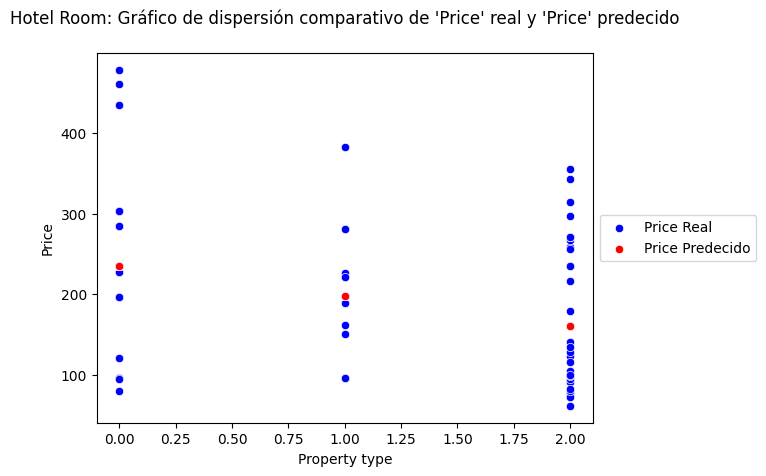

In [526]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_HR)
sns.scatterplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_HR)
#sns.lineplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_HR)

# Configurar el título, etiquetas y leyenda
plt.title("Hotel Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Property type")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [527]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Hotel_room","price_property_type","determinacion")] = coef_Deter
coef_Deter

0.10522102786750265

In [528]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Hotel_room","price_property_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.32437790903127584)

In [529]:
Grecia_HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   last_scraped                                  74 non-null     object 
 1   source                                        74 non-null     object 
 2   name                                          74 non-null     object 
 3   description                                   74 non-null     object 
 4   neighborhood_overview                         74 non-null     object 
 5   host_name                                     74 non-null     object 
 6   host_since                                    74 non-null     object 
 7   host_location                                 74 non-null     object 
 8   host_about                                    74 non-null     object 
 9   host_response_time                            74 non-null     objec

# Private Room

In [530]:
#Cargar desde un archivo .csv
Grecia_PR = pd.read_csv('room_type_Grecia/Private_room_Grecia.csv')

Grecia_PR.head()

,last_scraped,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,2024-09-23,city scrape,Lovely room in historic center,"relaxed, quiet area, next to all historic and ...",No disponible,Haris,2012-06-03,"Athens, Greece",Welcome in my profile on Airbnb! Infos about o...,within an hour,...,83,4.0,0.0,4.75,4.75,4.50,4.50,4.75,4.50,0.03
1,2024-09-23,city scrape,Room and private bathroom in Athens,Comfortable and quiet private bedroom with a k...,In my safe and easily accessible neighborhood ...,Nick,2014-04-06,"Athens, Greece","Hey , I'm Nick!",within an hour,...,29,42.9,5.0,4.92,4.97,4.91,4.96,4.87,4.93,3.09
2,2024-09-23,city scrape,Room with Balcony in Filopapos Hill,No disponible,No disponible,Sofia,2013-06-19,"Athens, Greece",I like traveling all over the world. It makes ...,a few days or more,...,362,15.0,0.0,4.73,4.87,5.00,5.00,4.73,4.80,0.11
3,2024-09-23,city scrape,Room with privet bathroom in Athens,Comfortable and quiet private bedroom with a p...,In my safe and easily accessible neighborhood ...,Nick,2014-04-06,"Athens, Greece","Hey , I'm Nick!",within an hour,...,52,42.9,3.0,4.93,4.95,4.96,4.95,4.87,4.94,3.08
4,2024-09-23,city scrape,Acropolis view-150 metres from Metro Monastiraki!,"My house is located in Monastiraki area, righ...",My neighborhood is the most charming area in A...,Makis,2014-05-06,"Athens, Greece",I am an actor and director. I like writing and...,within an hour,...,0,189.0,0.0,4.59,4.74,4.54,4.79,4.90,4.61,1.50


In [531]:
Grecia_PR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   last_scraped                 1007 non-null   object 
 1   source                       1007 non-null   object 
 2   name                         1007 non-null   object 
 3   description                  1007 non-null   object 
 4   neighborhood_overview        1007 non-null   object 
 5   host_name                    1007 non-null   object 
 6   host_since                   1007 non-null   object 
 7   host_location                1007 non-null   object 
 8   host_about                   1007 non-null   object 
 9   host_response_time           1007 non-null   object 
 10  host_is_superhost            1007 non-null   object 
 11  host_verifications           1007 non-null   object 
 12  host_identity_verified       1007 non-null   object 
 13  neighbourhood_clea

In [532]:
# Variables binarias: Convertir "yes" -> 1, "no" -> 0
binary_vars = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
for var in binary_vars:
    Grecia_PR[var] = Grecia_PR[var].map({'t': 1, 'f': 0})  # 't' (true) y 'f' (false) en el dataset

In [533]:
# Convertir "property_type" en variables numéricas label encoding
le = LabelEncoder()
Grecia_PR["property_type_encoded"] = le.fit_transform(Grecia_PR["property_type"])

In [534]:
comparaciones = [
    ("price", "host_acceptance_rate"),
    ("price", "host_is_superhost"),
    ("accommodates", "bathrooms"),
    ("price", "review_scores_cleanliness"),
    ("price", "host_identity_verified"),
    ("price", "instant_bookable")
]

In [535]:
#eliminamos la columna tipo string
df = Grecia_PR.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            1007 non-null   int64  
 1   host_identity_verified       1007 non-null   int64  
 2   instant_bookable             1007 non-null   int64  
 3   id                           1007 non-null   int64  
 4   host_response_rate           1007 non-null   float64
 5   host_acceptance_rate         1007 non-null   float64
 6   host_listings_count          1007 non-null   float64
 7   host_total_listings_count    1007 non-null   float64
 8   latitude                     1007 non-null   float64
 9   longitude                    1007 non-null   float64
 10  accommodates                 1007 non-null   float64
 11  bathrooms                    1007 non-null   float64
 12  bedrooms                     1007 non-null   float64
 13  beds              

In [536]:
#Encontramos todas las correlaciones entre las variables
corr_Factors = df.corr()
corr_Factors

,host_is_superhost,host_identity_verified,instant_bookable,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,...,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,property_type_encoded
host_is_superhost,1.000000,0.026301,0.013434,-0.056610,0.093175,-0.007587,0.123903,-0.004701,-0.103469,-0.061873,...,0.116315,0.214712,0.143046,0.103663,0.156181,0.072598,0.071452,0.123620,0.227532,-0.029580
host_identity_verified,0.026301,1.000000,0.100251,-0.139521,-0.056693,0.186101,0.036462,0.039404,-0.004409,0.039814,...,0.029426,0.040794,-0.068339,-0.059707,-0.072618,-0.048335,-0.037769,-0.040970,0.063891,0.046185
instant_bookable,0.013434,0.100251,1.000000,0.052708,-0.063068,0.334529,0.078017,0.130276,-0.258609,-0.103459,...,-0.027306,-0.055359,0.097058,0.096553,0.166206,0.061922,0.113299,0.064245,-0.034835,0.322438
id,-0.056610,-0.139521,0.052708,1.000000,-0.142000,-0.002440,-0.039368,0.064845,0.026537,0.004605,...,-0.392003,-0.097496,0.162023,0.090970,0.098521,0.084903,0.058454,0.121673,-0.096860,0.084285
host_response_rate,0.093175,-0.056693,-0.063068,-0.142000,1.000000,0.146204,0.018419,-0.087888,0.035427,-0.150068,...,0.089199,0.075089,-0.002871,-0.000454,0.014821,0.051616,-0.021490,0.040621,0.058497,-0.010488
host_acceptance_rate,-0.007587,0.186101,0.334529,-0.002440,0.146204,1.000000,0.022739,0.041592,-0.176150,-0.086653,...,0.055416,0.061047,0.047707,0.022111,0.131415,0.077658,0.098210,0.065650,0.058945,0.111264
host_listings_count,0.123903,0.036462,0.078017,-0.039368,0.018419,0.022739,1.000000,0.461306,-0.043570,0.042312,...,-0.061923,-0.054791,0.013181,-0.013084,-0.043200,-0.013137,0.001478,-0.008590,-0.084690,-0.067982
host_total_listings_count,-0.004701,0.039404,0.130276,0.064845,-0.087888,0.041592,0.461306,1.000000,-0.106066,-0.008610,...,-0.072023,-0.082436,0.051558,0.033528,0.028453,0.041048,0.045454,0.022921,-0.101294,0.112952
latitude,-0.103469,-0.004409,-0.258609,0.026537,0.035427,-0.176150,-0.043570,-0.106066,1.000000,0.128523,...,-0.043446,0.003409,-0.139116,-0.155407,-0.242693,-0.133971,-0.306840,-0.131143,-0.056684,-0.198781
longitude,-0.061873,0.039814,-0.103459,0.004605,-0.150068,-0.086653,0.042312,-0.008610,0.128523,1.000000,...,-0.028834,0.051364,-0.046833,-0.060360,-0.124966,-0.102428,0.041075,-0.050605,0.034725,-0.179557


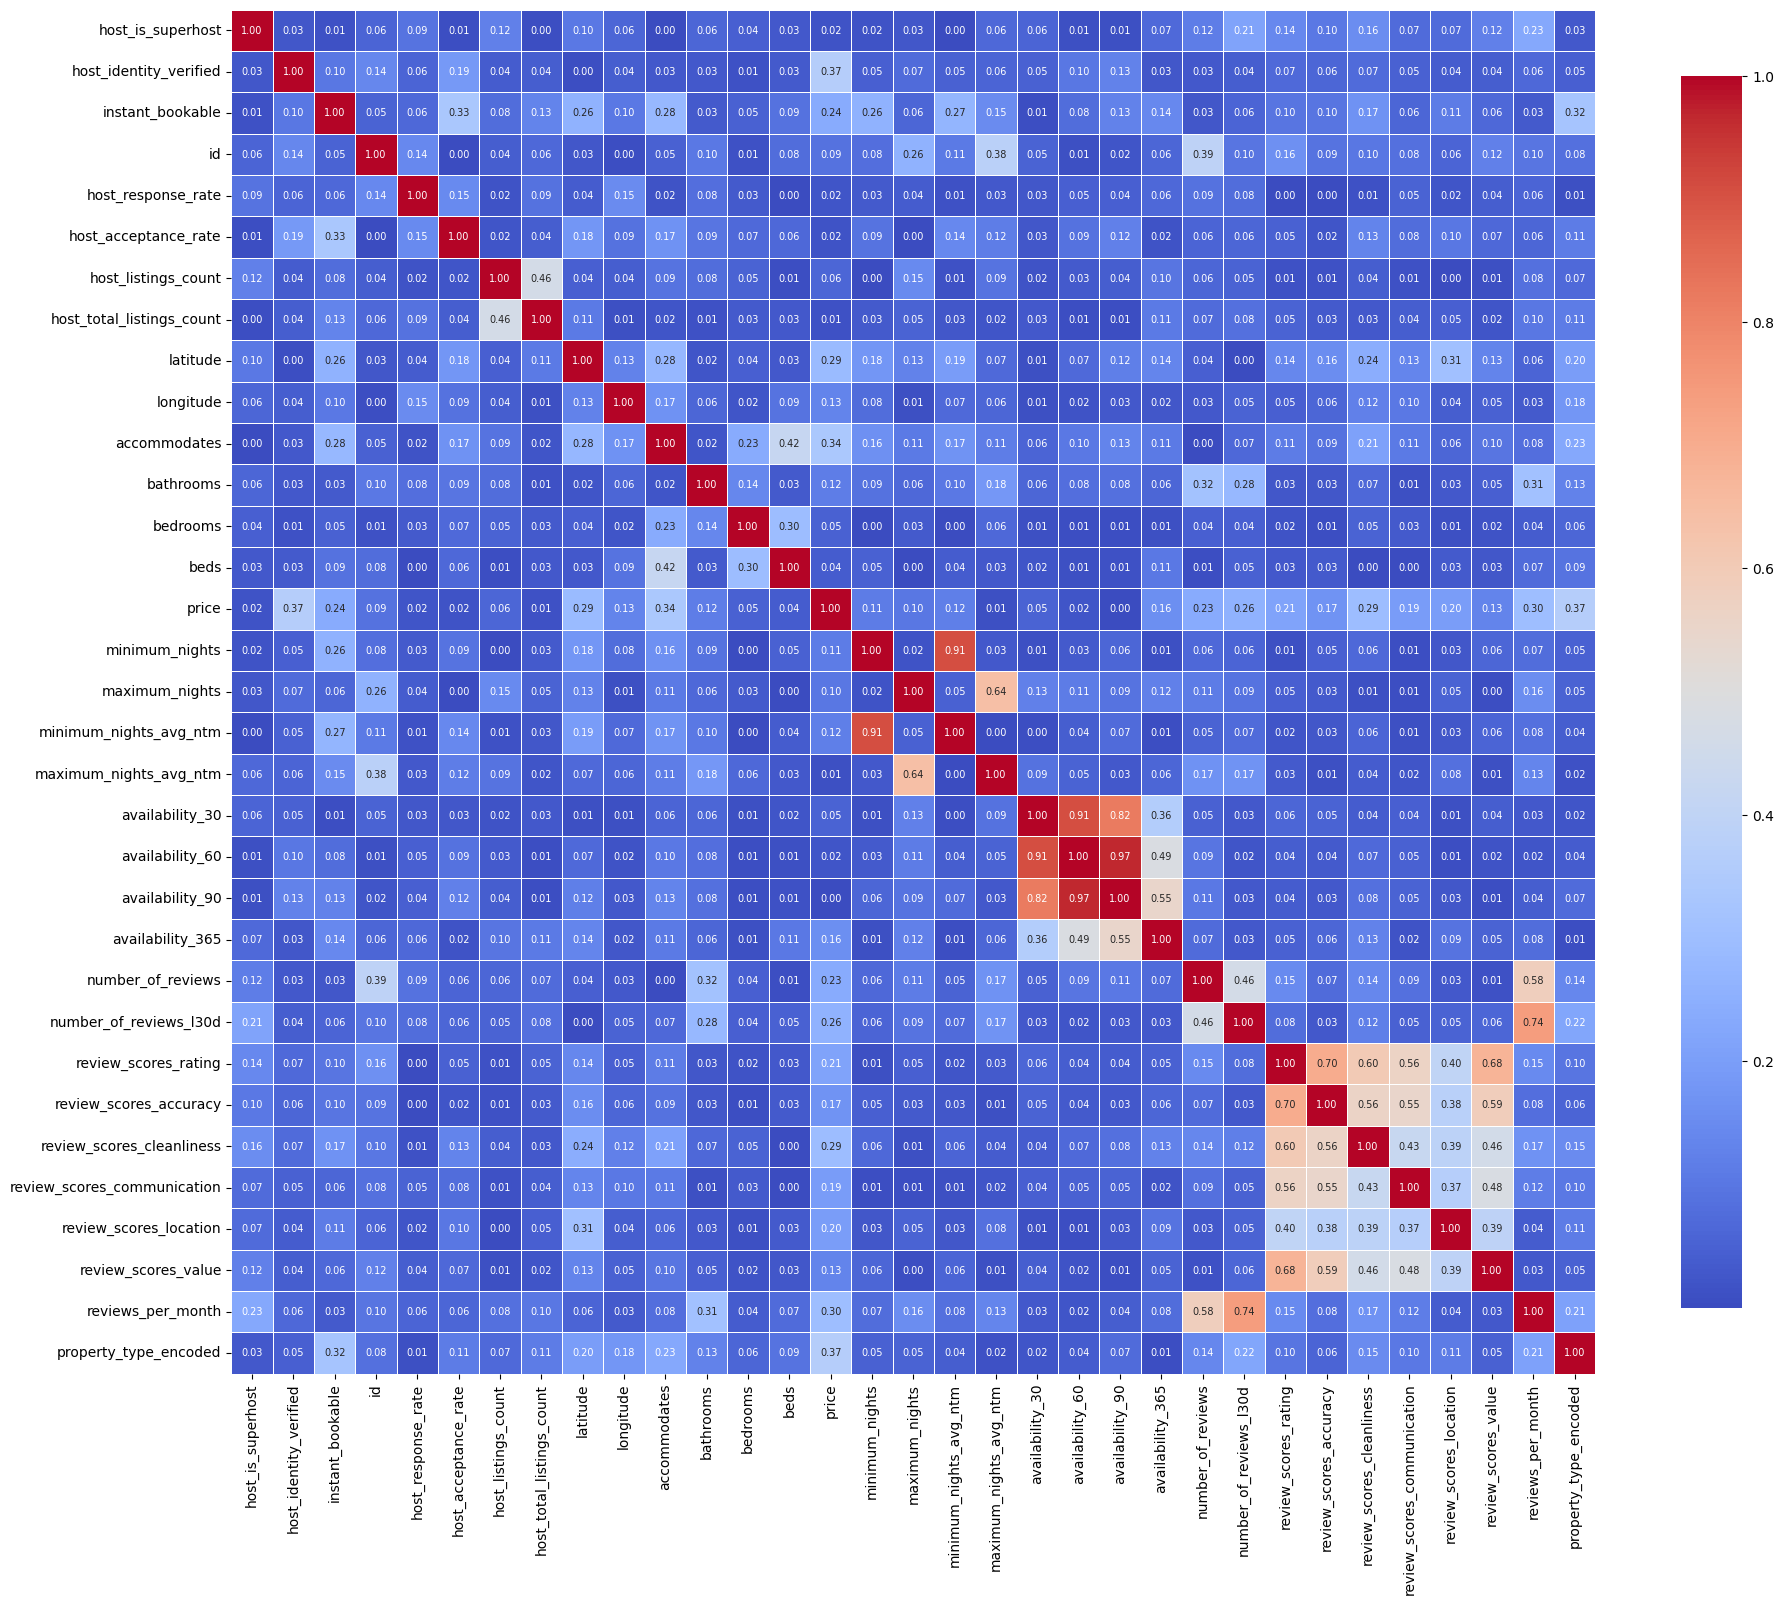

In [537]:
corr_Factors1 = abs(corr_Factors)
# Ajustar el tamaño de la figura
plt.figure(figsize=(22, 20))

# Crear una máscara para la mitad superior (opcional, si quieres ver solo la parte baja)
mask = np.triu(np.ones_like(corr_Factors1, dtype=bool))

# Crear el mapa de calor con mejoras
heat_map = sns.heatmap(
    corr_Factors1, 
    cmap="coolwarm",   # Mejora la diferenciación entre positivos y negativos
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True,       
    annot_kws={"size": 7},  # Reducimos el tamaño de los números internos
    cbar_kws={"shrink": 0.8}  # Hacemos la barra de colores más compacta
)

# Mejoramos la visibilidad de etiquetas
plt.xticks(rotation=90)  # Rota nombres en X para que no se encimen
plt.yticks(rotation=0)   # Mantiene etiquetas en Y horizontales

# Mostrar el gráfico
plt.show()

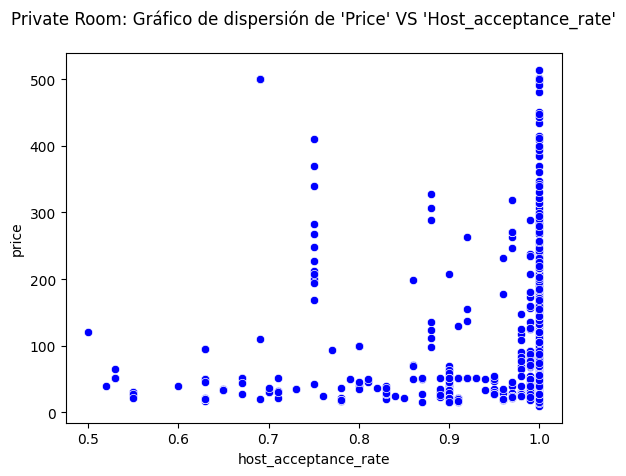

In [538]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(price vs host_acceptance_rate)
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Price' VS 'Host_acceptance_rate'\n")
# Mostrar la gráfica
plt.show()

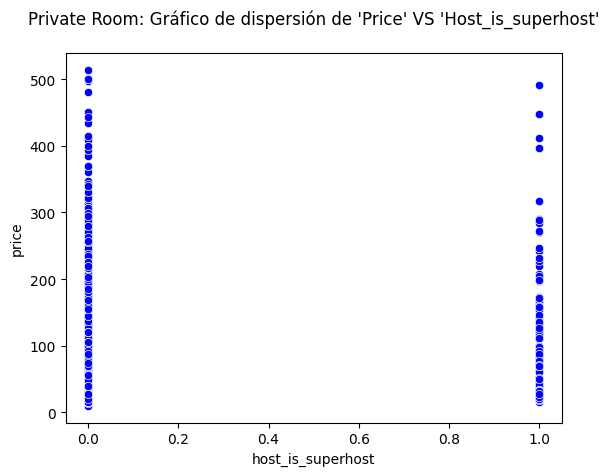

In [539]:
#(price vs host_is_superhost)
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Price' VS 'Host_is_superhost'\n")
# Mostrar la gráfica
plt.show()

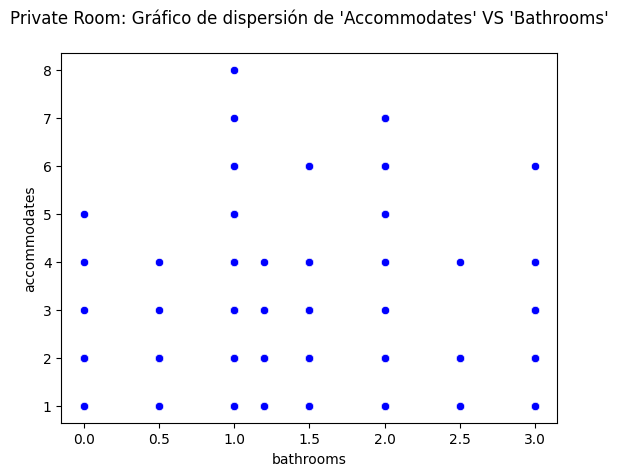

In [540]:
#(accommodates vs bathrooms)
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Accommodates' VS 'Bathrooms'\n")
# Mostrar la gráfica
plt.show()

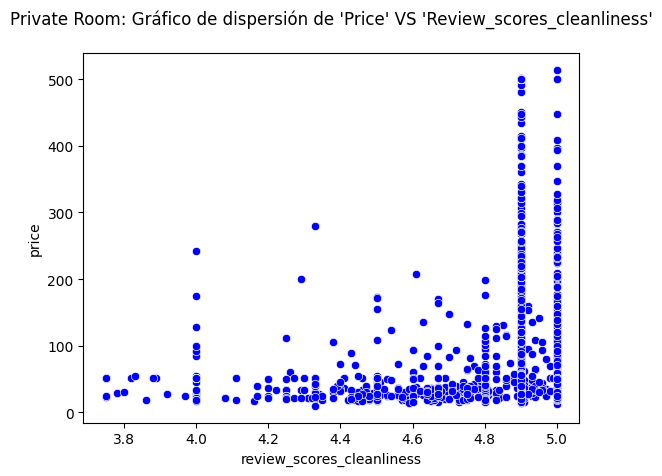

In [541]:
#(price vs review_scores_cleanliness)
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Price' VS 'Review_scores_cleanliness'\n")
# Mostrar la gráfica
plt.show()

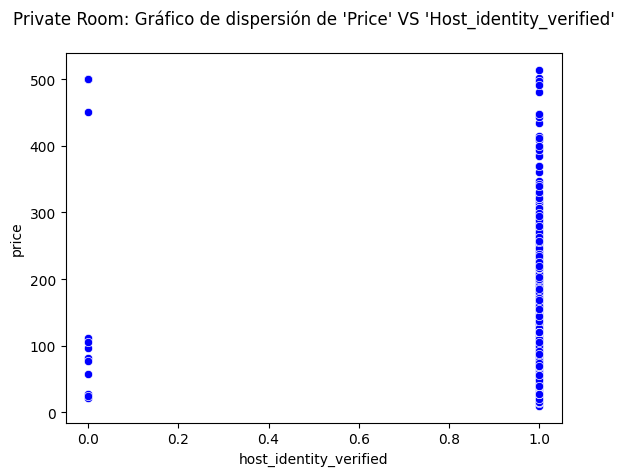

In [542]:
#(price vs host_identity_verified)
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Price' VS 'Host_identity_verified'\n")
# Mostrar la gráfica
plt.show()

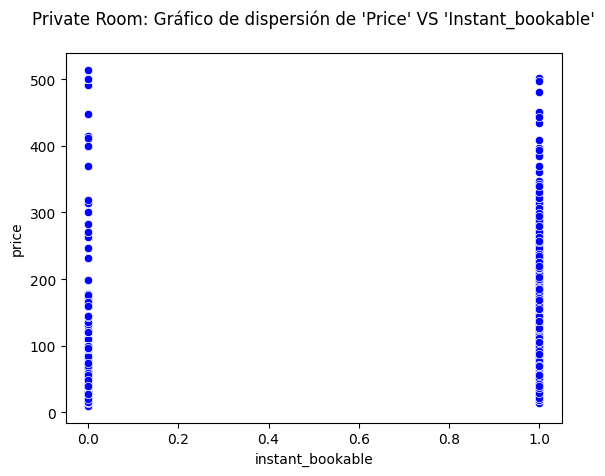

In [543]:
#(price vs instant_bookable)
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Price' VS 'Instant_bookable'\n")
# Mostrar la gráfica
plt.show()

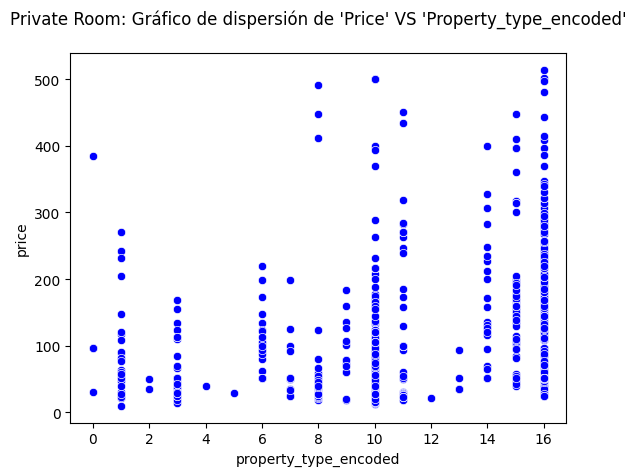

In [544]:
#(price vs property_type)
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_PR)
# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión de 'Price' VS 'Property_type_encoded'\n")
# Mostrar la gráfica
plt.show()

**| price vs host_acceptance_rate**

In [545]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['host_acceptance_rate']] 
var_Dep = Grecia_PR['price']

In [546]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [547]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [548]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([16.50554081]),
 'rank_': 1,
 'singular_': array([3.24466835]),
 'intercept_': np.float64(84.35557519143528)}

Modelo Matematico

In [549]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.00026212570083639086

In [550]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['host_acceptance_rate']])
y_pred

array([ 99.87078356, 100.861116  , 100.861116  , ..., 100.861116  ,
       100.6960606 , 100.861116  ], shape=(1007,))

In [551]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(22, 'Predicciones_price_host_acceptance_rate', y_pred)


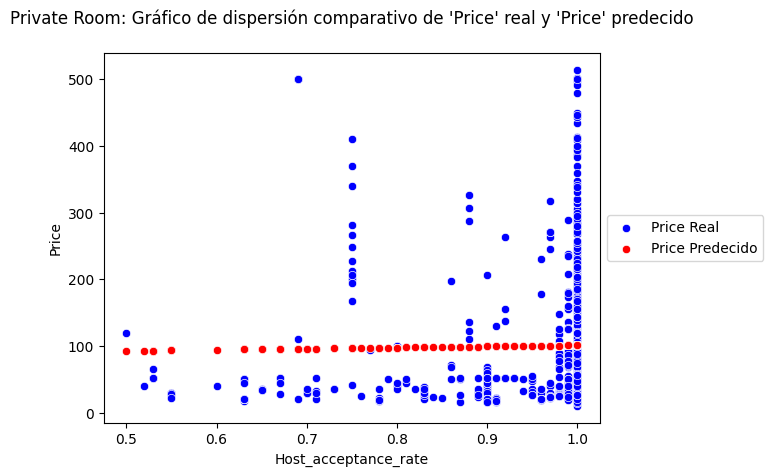

In [552]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_PR)
sns.scatterplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_PR)
#sns.lineplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host_acceptance_rate")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [553]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","price_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.00026212570083639086

In [554]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","price_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.01619029650242363)

**| price vs host_is_superhost**

In [555]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['host_is_superhost']] 
var_Dep = Grecia_PR['price']

In [556]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [557]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [558]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-5.28153518]),
 'rank_': 1,
 'singular_': array([11.7743599]),
 'intercept_': np.float64(100.84780023781212)}

Modelo Matematico

In [559]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.00035343082890959554

In [560]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['host_is_superhost']])
y_pred

array([ 95.56626506,  95.56626506, 100.84780024, ..., 100.84780024,
       100.84780024, 100.84780024], shape=(1007,))

In [561]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(10, 'Predicciones_price_host_is_superhost', y_pred)


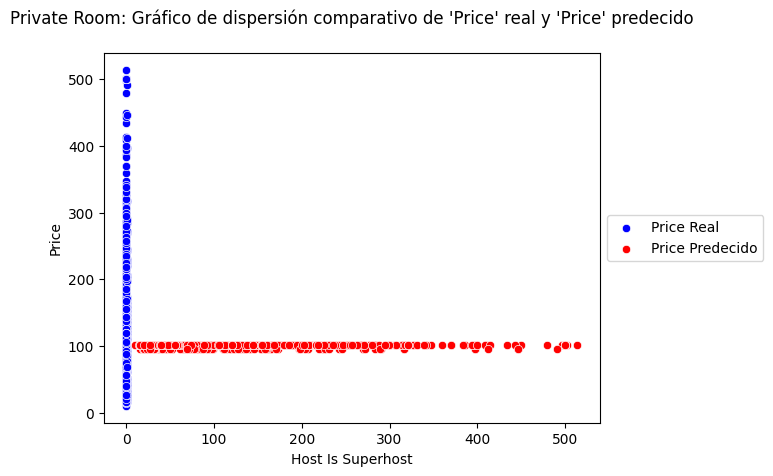

In [562]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_PR)
sns.scatterplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_PR)
#sns.lineplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Is Superhost")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [563]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","price_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.00035343082890959554

In [564]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","price_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.018799756086438874)

**| accommodates vs bathrooms**

In [565]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['bathrooms']] 
var_Dep = Grecia_PR['accommodates']

In [566]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [567]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [568]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.04255734]),
 'rank_': 1,
 'singular_': array([14.91769209]),
 'intercept_': np.float64(2.1469240988097473)}

Modelo Matematico

In [569]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.0004385350881864758

In [570]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['bathrooms']])
y_pred

array([2.18948144, 2.18948144, 2.18948144, ..., 2.18948144, 2.23203878,
       2.18948144], shape=(1007,))

In [571]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(29, 'Predicciones_bathrooms_accommodates', y_pred)


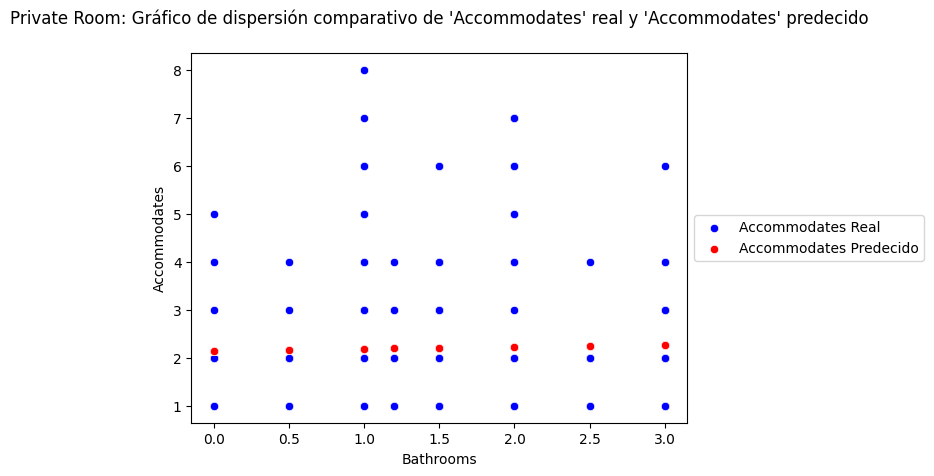

In [572]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_PR)
sns.scatterplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_PR)
#sns.lineplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Accommodates' real y 'Accommodates' predecido\n")
plt.xlabel("Bathrooms")
plt.ylabel("Accommodates")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [573]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","bathrooms_accommodates","determinacion")] = coef_Deter
coef_Deter

0.0004385350881864758

In [574]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","bathrooms_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.02094122938574705)

**| price vs review_scores_cleanliness**

In [575]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['review_scores_cleanliness']]
var_Dep = Grecia_PR['price']

In [576]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [577]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [578]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([116.53885249]),
 'rank_': 1,
 'singular_': array([8.36730066]),
 'intercept_': np.float64(-457.4106965256817)}

Modelo Matematico

In [579]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.08690038225990093

In [580]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['review_scores_cleanliness']])
y_pred

array([ 67.01413967, 114.79506919, 125.28356591, ..., 113.62968066,
       113.62968066, 113.62968066], shape=(1007,))

In [581]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(32, 'Predicciones_price_review_scores_cleanliness', y_pred)


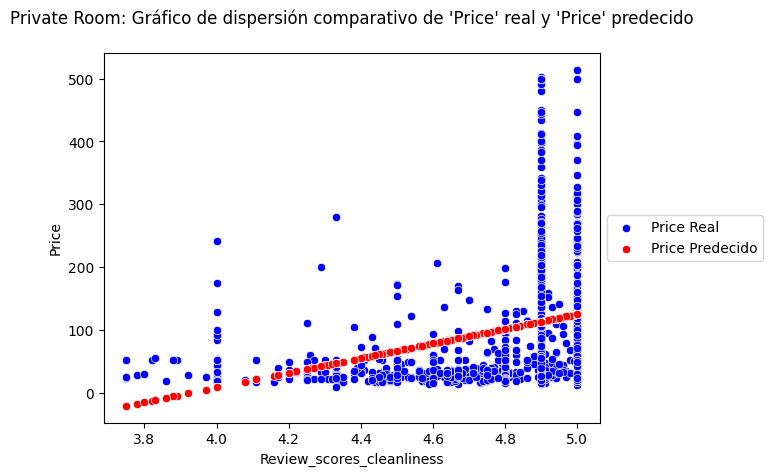

In [582]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_PR)
sns.scatterplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_PR)
#sns.lineplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Review_scores_cleanliness")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [583]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","price_review_scores_cleanliness","determinacion")] = coef_Deter
coef_Deter

0.08690038225990093

In [584]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","price_review_scores_cleanliness","correlacion")] = coef_Correl
coef_Correl

np.float64(0.2947887078229099)

**| price vs host_identity_verified**

In [585]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['host_identity_verified']]
var_Dep = Grecia_PR['price']

In [586]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [587]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [588]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_identity_verified'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-231.45863126]),
 'rank_': 1,
 'singular_': array([5.21741793]),
 'intercept_': np.float64(325.0000000000001)}

Modelo Matematico

In [589]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.13328076481862006

In [590]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['host_identity_verified']])
y_pred

array([93.54136874, 93.54136874, 93.54136874, ..., 93.54136874,
       93.54136874, 93.54136874], shape=(1007,))

In [591]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(32, 'Predicciones_price_host_identity_verified', y_pred)


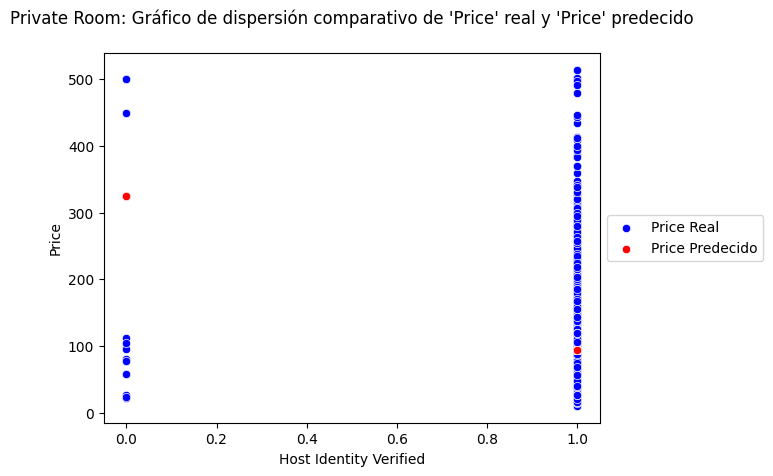

In [592]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_PR)
sns.scatterplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_PR)
#sns.lineplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Identity Verified")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [593]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","price_host_identity_verified","determinacion")] = coef_Deter
coef_Deter

0.13328076481862006

In [594]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","price_host_identity_verified","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3650763821703892)

**| price vs instant_bookable**

In [595]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['instant_bookable']]
var_Dep = Grecia_PR['price']

In [596]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [597]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [598]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([49.35854392]),
 'rank_': 1,
 'singular_': array([15.80171323]),
 'intercept_': np.float64(73.06768558951978)}

Modelo Matematico

In [599]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.055595865216627294

In [600]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['instant_bookable']])
y_pred

array([ 73.06768559, 122.42622951,  73.06768559, ...,  73.06768559,
        73.06768559, 122.42622951], shape=(1007,))

In [601]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(32, 'Predicciones_price_instant_bookable', y_pred)


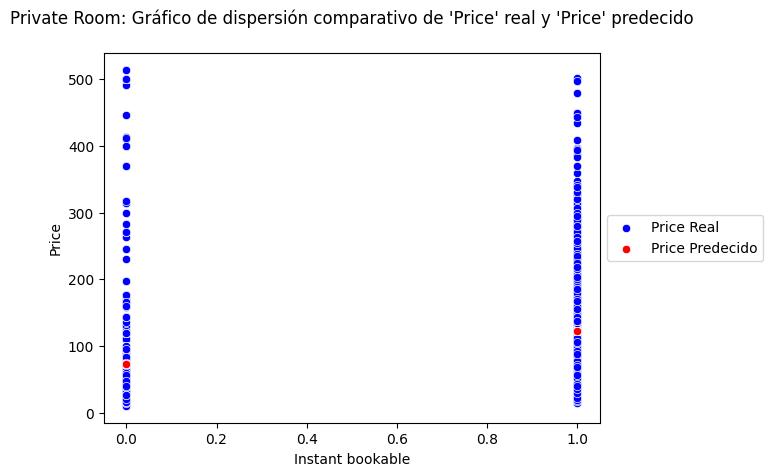

In [602]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_PR)
sns.scatterplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_PR)
#sns.lineplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Instant bookable")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [603]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","price_instant_bookable","determinacion")] = coef_Deter
coef_Deter

0.055595865216627294

In [604]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","price_instant_bookable","correlacion")] = coef_Correl
coef_Correl

np.float64(0.23578775459431156)

**| price vs property_type**

In [605]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_PR[['property_type_encoded']]
var_Dep = Grecia_PR['price']

In [606]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [607]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [608]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type_encoded'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([8.87420783]),
 'rank_': 1,
 'singular_': array([136.53603691]),
 'intercept_': np.float64(7.4633228968372265)}

Modelo Matematico

In [609]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.13417241586667383

In [610]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_PR[['property_type_encoded']])
y_pred

array([96.20540124, 34.0859464 , 78.45698557, ..., 96.20540124,
       96.20540124, 96.20540124], shape=(1007,))

In [611]:
#Insertamos la columna de predicciones en el dataframe
Grecia_PR.insert(32, 'Predicciones_price_property_type', y_pred)


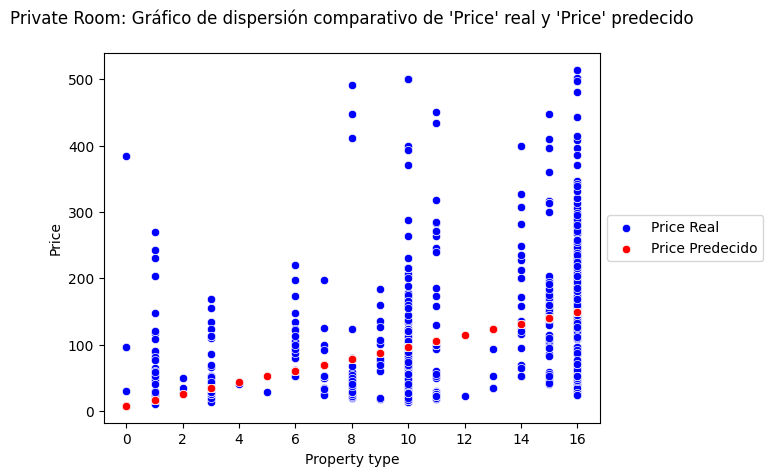

In [612]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_PR)
sns.scatterplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_PR)
#sns.lineplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_PR)

# Configurar el título, etiquetas y leyenda
plt.title("Private Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Property type")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [613]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Private_room","price_property_type","determinacion")] = coef_Deter
coef_Deter

0.13417241586667383

In [614]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Private_room","price_property_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3662955307762761)

In [615]:
Grecia_PR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   last_scraped                                  1007 non-null   object 
 1   source                                        1007 non-null   object 
 2   name                                          1007 non-null   object 
 3   description                                   1007 non-null   object 
 4   neighborhood_overview                         1007 non-null   object 
 5   host_name                                     1007 non-null   object 
 6   host_since                                    1007 non-null   object 
 7   host_location                                 1007 non-null   object 
 8   host_about                                    1007 non-null   object 
 9   host_response_time                            1007 non-null   o

# Shared Room

In [616]:
#Cargar desde un archivo .csv
Grecia_SR = pd.read_csv('room_type_Grecia/Shared_room_Grecia.csv')

Grecia_SR.head()

,last_scraped,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,2024-09-23,city scrape,Bedway Athens Hostel (Bed in female dormitory),"Bedway Athens Hostel is a brand new, modern Ho...",No disponible,Bedway Athens,2018-08-27,"Athens, Greece",No disponible,within a day,...,335,14.0,0.0,4.21,4.50,4.21,4.50,4.71,4.57,0.19
1,2024-09-23,city scrape,Bedway Athens Hostel (Bed in mixed dormitory),"Bedway Athens Hostel is a brand new, modern Ho...",No disponible,Bedway Athens,2018-08-27,"Athens, Greece",No disponible,within a day,...,174,33.0,1.0,4.70,4.61,4.55,4.76,4.82,4.88,0.45
2,2024-09-23,city scrape,Bedway Athens Hostel (Bed in mixed dormitory),"Bedway Athens Hostel is a brand new, modern Ho...",No disponible,Bedway Athens,2018-08-27,"Athens, Greece",No disponible,within a day,...,171,35.0,0.0,4.40,4.60,4.43,4.57,4.51,4.60,0.61
3,2024-09-23,city scrape,Bedway Athens Hostel (Bed in mixed dormitory),"Bedway Athens Hostel is a brand new, modern Ho...",No disponible,Bedway Athens,2018-08-27,"Athens, Greece",No disponible,within a day,...,179,8.0,0.0,3.88,3.88,3.88,4.90,3.88,3.88,0.20
4,2024-09-23,city scrape,Bedway Athens Hostel (Bed in female dormitory),"Bedway Athens Hostel is a brand new, modern Ho...",No disponible,Bedway Athens,2018-08-27,"Athens, Greece",No disponible,within a day,...,179,1.0,0.0,4.00,5.00,4.80,5.00,5.00,4.00,0.02


In [617]:
Grecia_SR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   last_scraped                 55 non-null     object 
 1   source                       55 non-null     object 
 2   name                         55 non-null     object 
 3   description                  55 non-null     object 
 4   neighborhood_overview        55 non-null     object 
 5   host_name                    55 non-null     object 
 6   host_since                   55 non-null     object 
 7   host_location                55 non-null     object 
 8   host_about                   55 non-null     object 
 9   host_response_time           55 non-null     object 
 10  host_is_superhost            55 non-null     object 
 11  host_verifications           55 non-null     object 
 12  host_identity_verified       55 non-null     object 
 13  neighbourhood_cleansed

In [618]:
# Variables binarias: Convertir "yes" -> 1, "no" -> 0
binary_vars = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
for var in binary_vars:
    Grecia_SR[var] = Grecia_SR[var].map({'t': 1, 'f': 0})  # 't' (true) y 'f' (false) en el dataset

In [619]:
# Convertir "property_type" en variables numéricas label encoding
le = LabelEncoder()
Grecia_SR["property_type_encoded"] = le.fit_transform(Grecia_SR["property_type"])

In [620]:
comparaciones = [
    ("price", "host_acceptance_rate"),
    ("price", "host_is_superhost"),
    ("accommodates", "bathrooms"),
    ("price", "review_scores_cleanliness"),
    ("price", "host_identity_verified"),
    ("price", "instant_bookable")
]

In [621]:
#eliminamos la columna tipo string
df = Grecia_SR.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            55 non-null     int64  
 1   host_identity_verified       55 non-null     int64  
 2   instant_bookable             55 non-null     int64  
 3   id                           55 non-null     int64  
 4   host_response_rate           55 non-null     float64
 5   host_acceptance_rate         55 non-null     float64
 6   host_listings_count          55 non-null     float64
 7   host_total_listings_count    55 non-null     float64
 8   latitude                     55 non-null     float64
 9   longitude                    55 non-null     float64
 10  accommodates                 55 non-null     float64
 11  bathrooms                    55 non-null     float64
 12  bedrooms                     55 non-null     float64
 13  beds                  

In [622]:
#Encontramos todas las correlaciones entre las variables
corr_Factors = df.corr()
corr_Factors

,host_is_superhost,host_identity_verified,instant_bookable,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,...,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,property_type_encoded
host_is_superhost,1.000000,0.279070,0.147495,0.540242,0.053062,0.130059,0.550321,-0.017306,0.014849,-0.311447,...,-0.216260,0.063666,0.266568,0.333331,0.271884,0.301384,-0.004806,0.259338,-0.013293,0.406977
host_identity_verified,0.279070,1.000000,0.205210,0.131247,-0.377329,0.137182,-0.191931,0.044502,-0.212728,-0.092840,...,-0.004010,0.023875,0.038299,0.117653,-0.111238,-0.067273,-0.318232,0.052527,0.166238,0.041754
instant_bookable,0.147495,0.205210,1.000000,0.157797,0.307270,0.772459,-0.002614,0.222251,0.398723,-0.660563,...,0.097484,-0.138252,0.045987,0.180732,0.165978,0.131339,-0.246474,-0.023902,0.018496,-0.001588
id,0.540242,0.131247,0.157797,1.000000,0.372326,0.380662,-0.011424,-0.335810,0.633481,-0.209764,...,-0.442473,-0.012162,0.305209,0.430002,0.539182,0.376391,0.006146,0.120340,-0.091354,-0.090613
host_response_rate,0.053062,-0.377329,0.307270,0.372326,1.000000,0.674864,0.092911,0.254752,0.744376,-0.015030,...,-0.084327,0.165439,0.255416,0.232413,0.513659,0.264390,-0.058553,0.165419,0.101708,-0.190400
host_acceptance_rate,0.130059,0.137182,0.772459,0.380662,0.674864,1.000000,-0.103658,0.222399,0.687836,-0.555395,...,0.054454,0.005133,0.216995,0.301918,0.289713,0.220414,-0.215500,0.129501,0.151661,-0.062021
host_listings_count,0.550321,-0.191931,-0.002614,-0.011424,0.092911,-0.103658,1.000000,0.572790,-0.154599,-0.206092,...,-0.047066,0.072166,0.045931,0.101281,0.158272,0.227567,0.017382,0.133114,-0.051950,0.491976
host_total_listings_count,-0.017306,0.044502,0.222251,-0.335810,0.254752,0.222399,0.572790,1.000000,-0.022974,-0.061994,...,0.167970,0.086465,0.066650,0.092237,0.102029,0.013045,-0.302836,0.152242,0.202865,0.223166
latitude,0.014849,-0.212728,0.398723,0.633481,0.744376,0.687836,-0.154599,-0.022974,1.000000,-0.286050,...,-0.168409,0.006742,0.221927,0.297870,0.431033,0.268776,-0.004414,0.071657,0.031536,-0.317655
longitude,-0.311447,-0.092840,-0.660563,-0.209764,-0.015030,-0.555395,-0.206092,-0.061994,-0.286050,1.000000,...,-0.112100,0.145266,-0.016555,-0.166517,0.063640,-0.107605,0.035796,0.012403,-0.002380,-0.177898


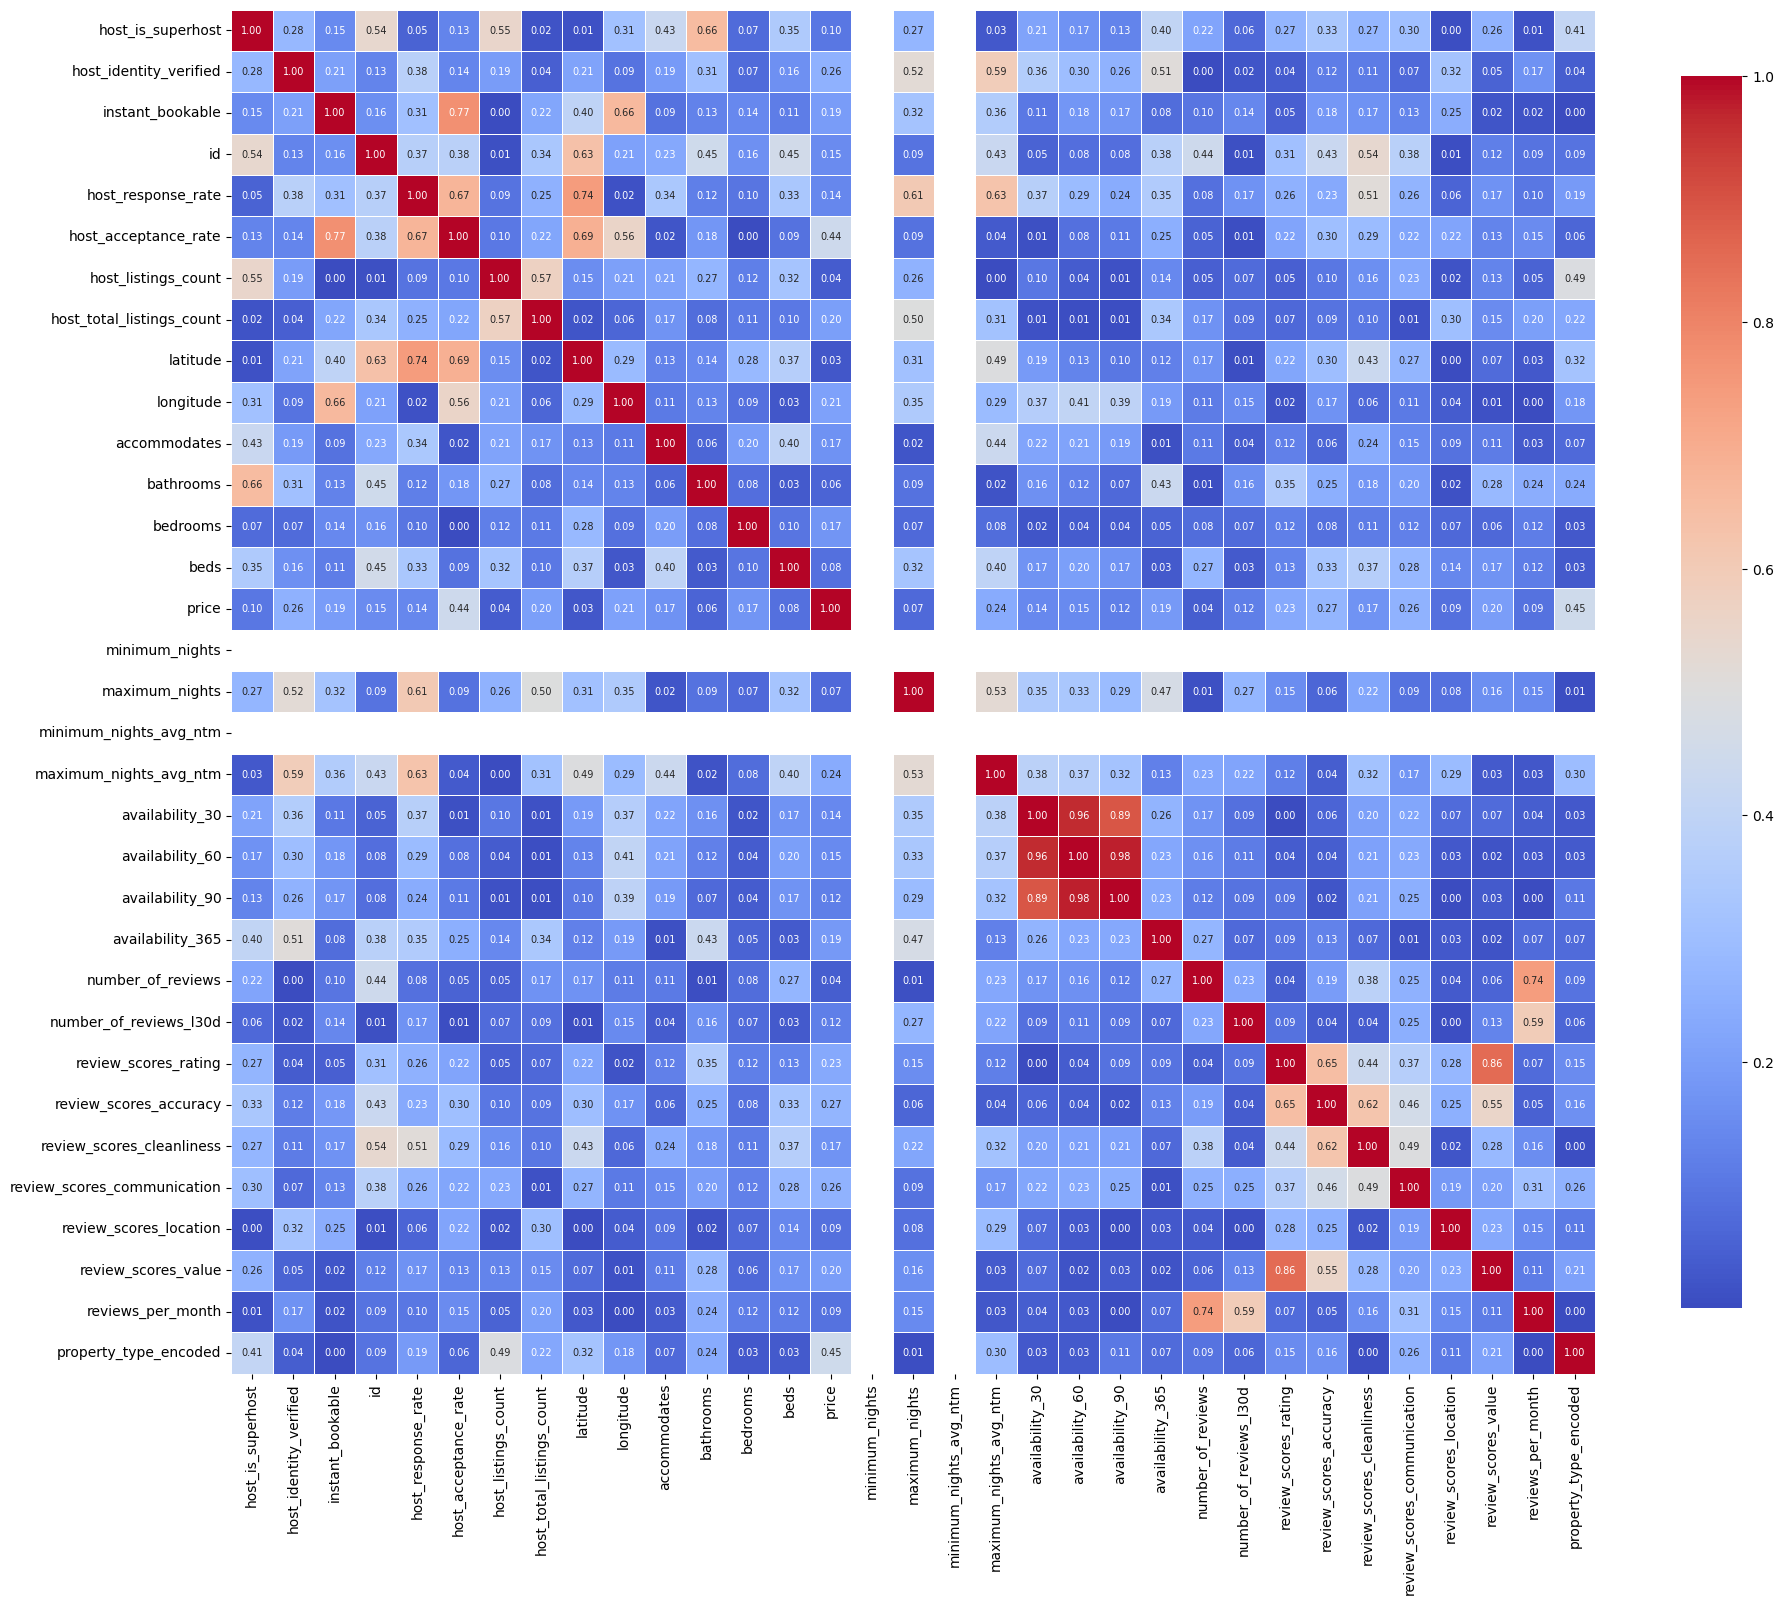

In [623]:
corr_Factors1 = abs(corr_Factors)
# Ajustar el tamaño de la figura
plt.figure(figsize=(22, 20))

# Crear una máscara para la mitad superior (opcional, si quieres ver solo la parte baja)
mask = np.triu(np.ones_like(corr_Factors1, dtype=bool))

# Crear el mapa de calor con mejoras
heat_map = sns.heatmap(
    corr_Factors1, 
    cmap="coolwarm",   # Mejora la diferenciación entre positivos y negativos
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True,       
    annot_kws={"size": 7},  # Reducimos el tamaño de los números internos
    cbar_kws={"shrink": 0.8}  # Hacemos la barra de colores más compacta
)

# Mejoramos la visibilidad de etiquetas
plt.xticks(rotation=90)  # Rota nombres en X para que no se encimen
plt.yticks(rotation=0)   # Mantiene etiquetas en Y horizontales

# Mostrar el gráfico
plt.show()

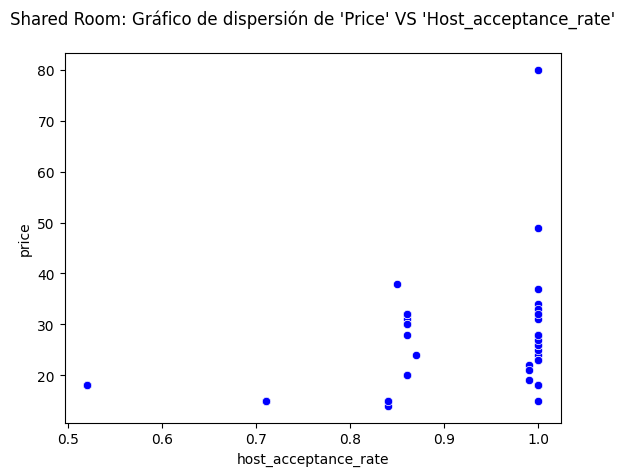

In [624]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(price vs host_acceptance_rate)
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Price' VS 'Host_acceptance_rate'\n")
# Mostrar la gráfica
plt.show()

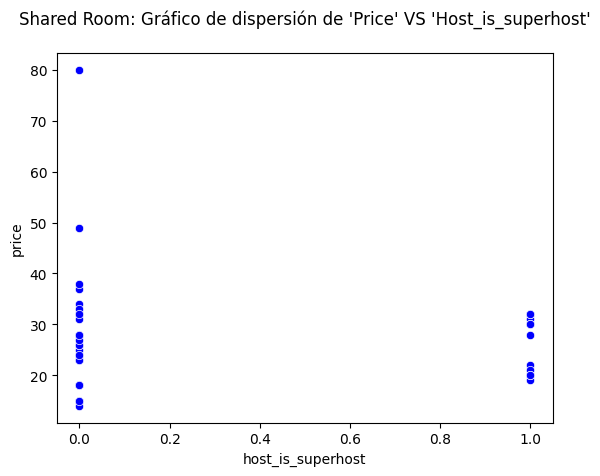

In [625]:
#(price vs host_is_superhost)
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Price' VS 'Host_is_superhost'\n")
# Mostrar la gráfica
plt.show()

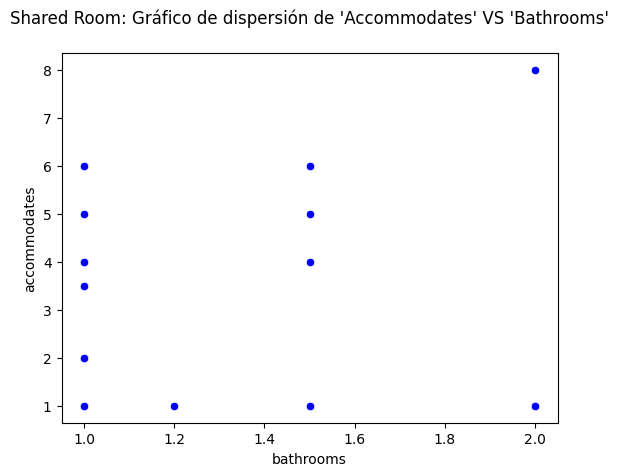

In [626]:
#(accommodates vs bathrooms)
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Accommodates' VS 'Bathrooms'\n")
# Mostrar la gráfica
plt.show()

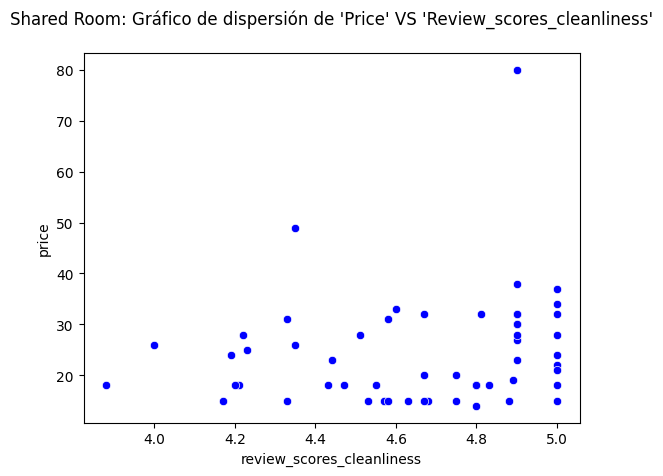

In [627]:
#(price vs review_scores_cleanliness)
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Price' VS 'Review_scores_cleanliness'\n")
# Mostrar la gráfica
plt.show()

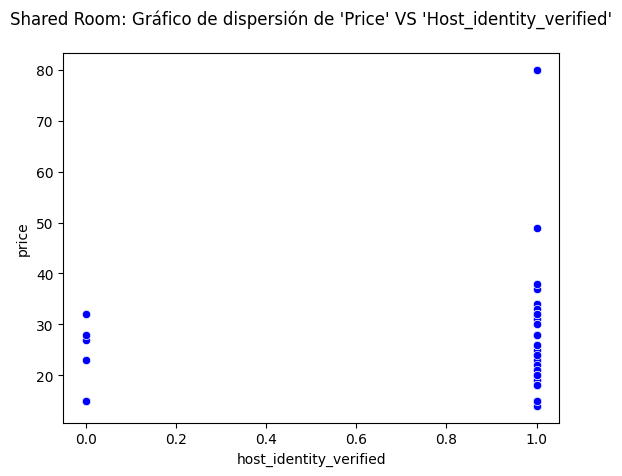

In [628]:
#(price vs host_identity_verified)
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Price' VS 'Host_identity_verified'\n")
# Mostrar la gráfica
plt.show()

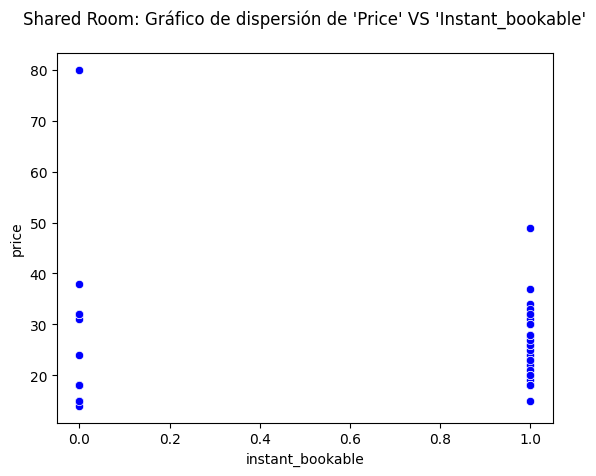

In [629]:
#(price vs instant_bookable)
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Price' VS 'Instant_bookable'\n")
# Mostrar la gráfica
plt.show()

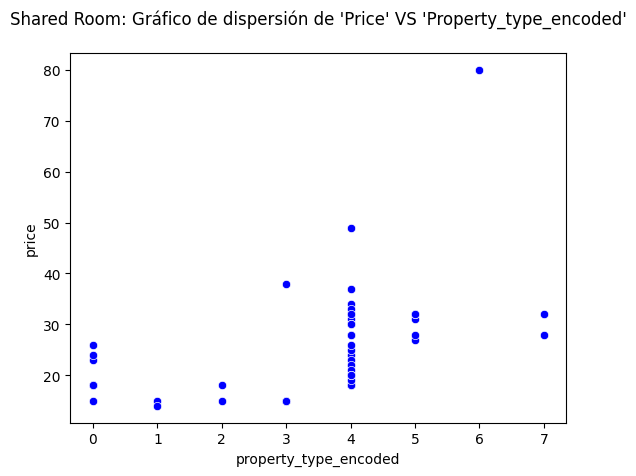

In [630]:
#(price vs property_type)
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_SR)
# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión de 'Price' VS 'Property_type_encoded'\n")
# Mostrar la gráfica
plt.show()

**| price vs host_acceptance_rate**

In [631]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['host_acceptance_rate']]
var_Dep = Grecia_SR['price'] 

In [632]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [633]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [634]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([27.93028453]),
 'rank_': 1,
 'singular_': array([1.25832067]),
 'intercept_': np.float64(0.638945219290477)}

Modelo Matematico

In [635]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.1951571925120219

In [636]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['host_acceptance_rate']])
y_pred

array([15.16269317, 15.16269317, 15.16269317, 15.16269317, 15.16269317,
       15.16269317, 15.16269317, 15.16269317, 20.46944723, 20.46944723,
       28.56922974, 28.56922974, 28.56922974, 28.56922974, 28.56922974,
       28.56922974, 20.46944723, 20.46944723, 20.46944723, 20.46944723,
       20.46944723, 20.46944723, 28.56922974, 28.56922974, 28.56922974,
       28.56922974, 28.56922974, 28.56922974, 28.56922974, 28.56922974,
       28.2899269 , 28.2899269 , 28.2899269 , 28.56922974, 24.65898991,
       28.56922974, 28.56922974, 28.56922974, 24.65898991, 24.65898991,
       24.65898991, 24.65898991, 24.10038422, 28.56922974, 28.56922974,
       28.56922974, 28.56922974, 24.65898991, 24.10038422, 24.93829276,
       24.65898991, 24.65898991, 24.10038422, 24.37968707, 24.65898991])

In [637]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(22, 'Predicciones_price_host_acceptance_rate', y_pred)


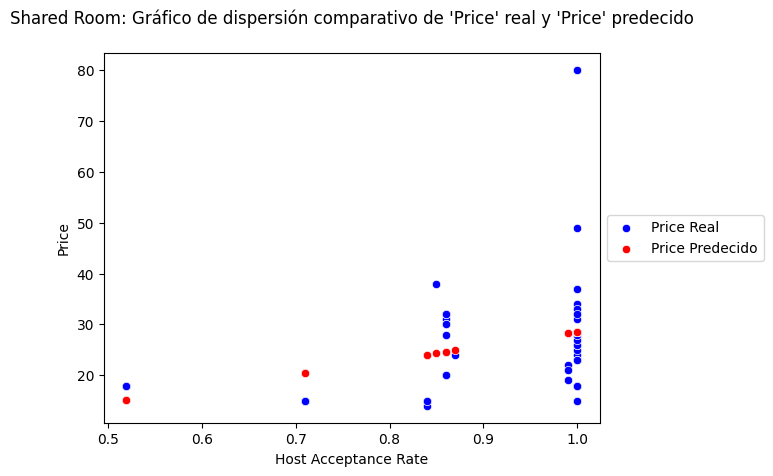

In [638]:
# Graficar los puntos
sns.scatterplot(x='host_acceptance_rate', y='price', color="blue", data=Grecia_SR)
sns.scatterplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_SR)
#sns.lineplot(x='host_acceptance_rate', y='Predicciones_price_host_acceptance_rate', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Acceptance Rate")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [639]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","price_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.1951571925120219

In [640]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","price_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.4417659929329349)

**| price vs host_is_superhost**

In [641]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['host_is_superhost']]
var_Dep = Grecia_SR['price'] 

In [642]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [643]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [644]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.57945736]),
 'rank_': 1,
 'singular_': array([3.06297538]),
 'intercept_': np.float64(23.83720930232558)}

Modelo Matematico

In [645]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.00986267904585958

In [646]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['host_is_superhost']])
y_pred

array([23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 ,
       23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 ,
       23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 ,
       23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 ,
       23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 ,
       23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 , 23.8372093 ,
       26.41666667, 26.41666667, 26.41666667, 23.8372093 , 26.41666667,
       23.8372093 , 23.8372093 , 23.8372093 , 26.41666667, 26.41666667,
       26.41666667, 26.41666667, 23.8372093 , 23.8372093 , 23.8372093 ,
       23.8372093 , 23.8372093 , 26.41666667, 23.8372093 , 23.8372093 ,
       26.41666667, 26.41666667, 23.8372093 , 23.8372093 , 26.41666667])

In [647]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(10, 'Predicciones_price_host_is_superhost', y_pred)


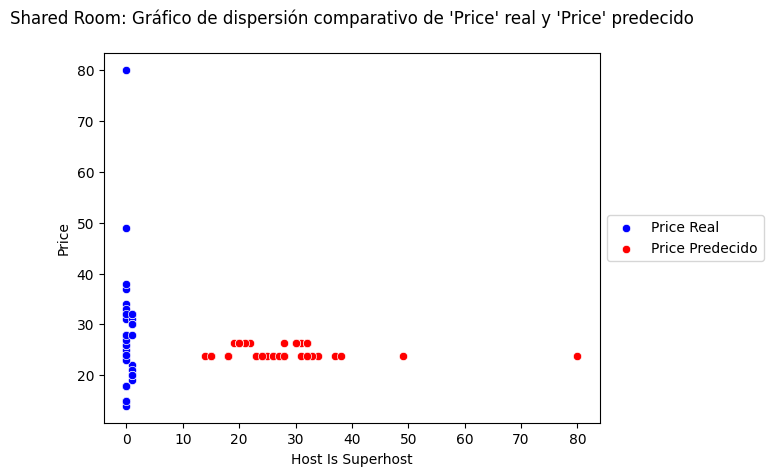

In [648]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_is_superhost', y='price', color="blue", data=Grecia_SR)
sns.scatterplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_SR)
#sns.lineplot(x='price', y='Predicciones_price_host_is_superhost', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Is Superhost")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [649]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","price_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.00986267904585958

In [650]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","price_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.0993110217743206)

**| accommodates vs bathrooms**

In [651]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['bathrooms']]
var_Dep = Grecia_SR['accommodates'] 

In [652]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [653]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [654]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.34732505]),
 'rank_': 1,
 'singular_': array([2.37662863]),
 'intercept_': np.float64(1.915534668125925)}

Modelo Matematico

In [655]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.0035936494110888617

In [656]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['bathrooms']])
y_pred

array([2.26285972, 2.26285972, 2.26285972, 2.26285972, 2.26285972,
       2.26285972, 2.26285972, 2.26285972, 2.26285972, 2.26285972,
       2.26285972, 2.26285972, 2.26285972, 2.26285972, 2.26285972,
       2.43652224, 2.26285972, 2.26285972, 2.26285972, 2.26285972,
       2.26285972, 2.26285972, 2.26285972, 2.26285972, 2.26285972,
       2.26285972, 2.61018477, 2.26285972, 2.26285972, 2.26285972,
       2.61018477, 2.43652224, 2.43652224, 2.26285972, 2.26285972,
       2.26285972, 2.26285972, 2.26285972, 2.43652224, 2.26285972,
       2.43652224, 2.43652224, 2.43652224, 2.26285972, 2.26285972,
       2.26285972, 2.26285972, 2.43652224, 2.43652224, 2.33232473,
       2.61018477, 2.61018477, 2.43652224, 2.26285972, 2.61018477])

In [657]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(29, 'Predicciones_bathrooms_accommodates', y_pred)


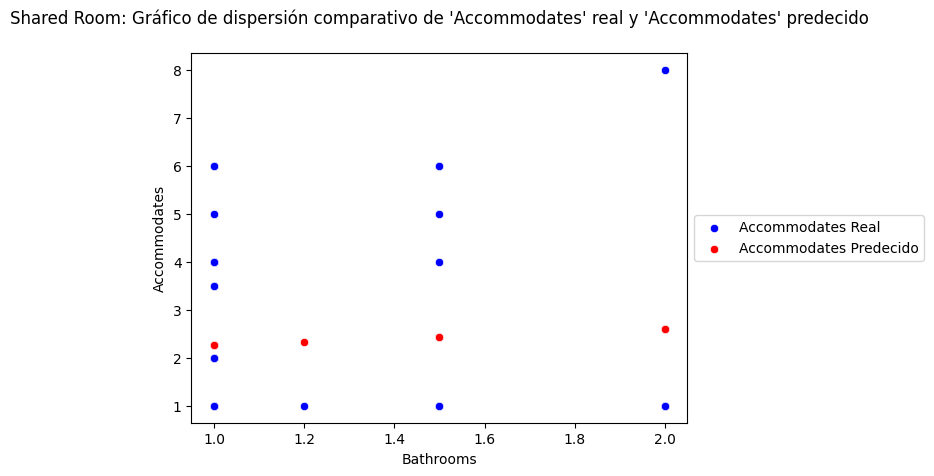

In [658]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='bathrooms', y='accommodates', color="blue", data=Grecia_SR)
sns.scatterplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_SR)
#sns.lineplot(x='bathrooms', y='Predicciones_bathrooms_accommodates', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Accommodates' real y 'Accommodates' predecido\n")
plt.xlabel("Bathrooms")
plt.ylabel("Accommodates")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [659]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","bathrooms_accommodates","determinacion")] = coef_Deter
coef_Deter

0.0035936494110888617

In [660]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","bathrooms_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.05994705506602357)

**| price vs review_scores_cleanliness**

In [661]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['review_scores_cleanliness']]
var_Dep = Grecia_SR['price'] 

In [662]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [663]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [664]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([6.3041188]),
 'rank_': 1,
 'singular_': array([2.17454697]),
 'intercept_': np.float64(-4.971462572478828)}

Modelo Matematico

In [665]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.029691869637565094

In [666]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['review_scores_cleanliness']])
y_pred

array([21.56887756, 23.71227795, 22.95578369, 19.48851836, 25.28830765,
       21.50583637, 25.47743121, 23.20794845, 24.97310171, 23.83836033,
       22.45145419, 21.44279518, 21.63191875, 21.69495993, 22.45145419,
       20.24501261, 24.21660745, 23.58619557, 23.90140151, 22.32537181,
       25.79263715, 24.53181339, 26.54913141, 26.54913141, 26.54913141,
       23.90140151, 23.4601132 , 24.02748389, 23.01882488, 25.91871953,
       25.85567834, 26.54913141, 26.54913141, 24.46877221, 24.46877221,
       25.28830765, 26.54913141, 25.28830765, 25.35134884, 24.97310171,
       22.32537181, 24.46877221, 21.31671281, 25.91871953, 25.91871953,
       26.54913141, 25.91871953, 25.91871953, 25.28830765, 26.54913141,
       25.91871953, 25.91871953, 26.54913141, 25.91871953, 25.91871953])

In [667]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(32, 'Predicciones_price_review_scores_cleanliness', y_pred)


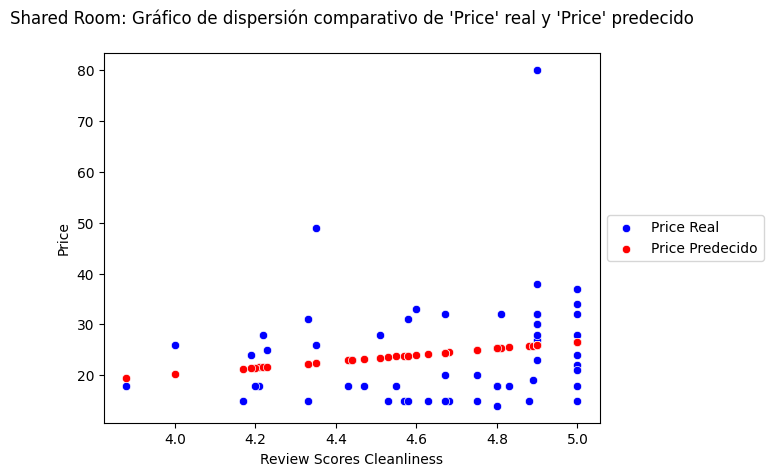

In [668]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='review_scores_cleanliness', y='price', color="blue", data=Grecia_SR)
sns.scatterplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_SR)
#sns.lineplot(x='review_scores_cleanliness', y='Predicciones_price_review_scores_cleanliness', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Review Scores Cleanliness")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [669]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","price_review_scores_cleanliness","determinacion")] = coef_Deter
coef_Deter

0.029691869637565094

In [670]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","price_review_scores_cleanliness","correlacion")] = coef_Correl
coef_Correl

np.float64(0.172313289207667)

**| price vs host_identity_verified**

In [671]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['host_identity_verified']]
var_Dep = Grecia_SR['price'] 

In [672]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [673]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [674]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_identity_verified'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([6.69379845]),
 'rank_': 1,
 'singular_': array([3.06297538]),
 'intercept_': np.float64(19.166666666666668)}

Modelo Matematico

In [675]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.06641764245649662

In [676]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['host_identity_verified']])
y_pred

array([25.86046512, 25.86046512, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 25.86046512, 25.86046512, 19.16666667, 19.16666667,
       25.86046512, 25.86046512, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 19.16666667, 19.16666667, 19.16666667, 19.16666667,
       19.16666667, 19.16666667, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 25.86046512, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 25.86046512, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 25.86046512, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 25.86046512, 25.86046512, 19.16666667, 19.16666667,
       19.16666667, 19.16666667, 25.86046512, 25.86046512, 25.86046512,
       25.86046512, 25.86046512, 25.86046512, 25.86046512, 25.86046512])

In [677]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(32, 'Predicciones_price_host_identity_verified', y_pred)


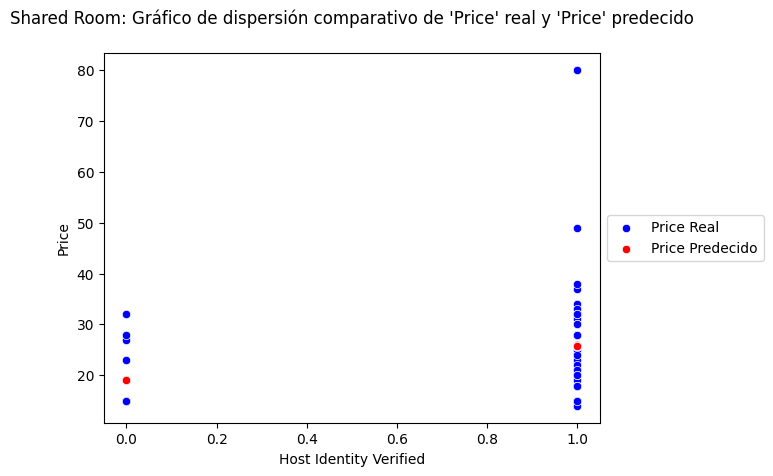

In [678]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='host_identity_verified', y='price', color="blue", data=Grecia_SR)
sns.scatterplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_SR)
#sns.lineplot(x='host_identity_verified', y='Predicciones_price_host_identity_verified', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Host Identity Verified")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [679]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","price_host_identity_verified","determinacion")] = coef_Deter
coef_Deter

0.06641764245649662

In [680]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","price_host_identity_verified","correlacion")] = coef_Correl
coef_Correl

np.float64(0.25771620526559175)

**| price vs instant_bookable**

In [681]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['instant_bookable']]
var_Dep = Grecia_SR['price'] 

In [682]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [683]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [684]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['instant_bookable'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([4.18700265]),
 'rank_': 1,
 'singular_': array([3.70257895]),
 'intercept_': np.float64(22.19230769230769)}

Modelo Matematico

In [685]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.03797224803366006

In [686]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['instant_bookable']])
y_pred

array([22.19230769, 22.19230769, 22.19230769, 22.19230769, 22.19230769,
       22.19230769, 22.19230769, 22.19230769, 22.19230769, 22.19230769,
       26.37931034, 26.37931034, 26.37931034, 26.37931034, 26.37931034,
       26.37931034, 22.19230769, 22.19230769, 22.19230769, 22.19230769,
       22.19230769, 22.19230769, 26.37931034, 26.37931034, 26.37931034,
       26.37931034, 26.37931034, 26.37931034, 26.37931034, 22.19230769,
       26.37931034, 26.37931034, 26.37931034, 26.37931034, 26.37931034,
       26.37931034, 26.37931034, 26.37931034, 22.19230769, 26.37931034,
       22.19230769, 22.19230769, 22.19230769, 26.37931034, 26.37931034,
       26.37931034, 26.37931034, 22.19230769, 22.19230769, 22.19230769,
       26.37931034, 26.37931034, 22.19230769, 22.19230769, 26.37931034])

In [687]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(32, 'Predicciones_price_instant_bookable', y_pred)


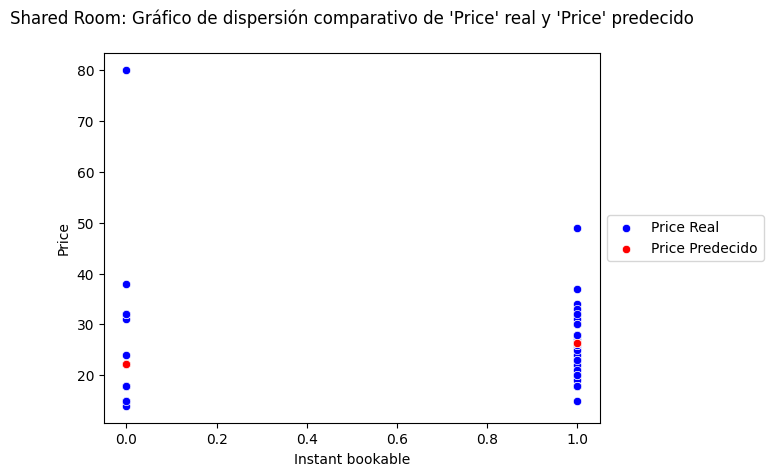

In [688]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='instant_bookable', y='price', color="blue", data=Grecia_SR)
sns.scatterplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_SR)
#sns.lineplot(x='instant_bookable', y='Predicciones_price_instant_bookable', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Instant bookable")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [689]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","price_instant_bookable","determinacion")] = coef_Deter
coef_Deter

0.03797224803366006

In [690]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","price_instant_bookable","correlacion")] = coef_Correl
coef_Correl

np.float64(0.1948646916033278)

**| price vs property_type**

In [691]:
#Declaramos las variables dependientes e independientes para la regresión lineal
vars_Indep = Grecia_SR[['property_type_encoded']]
var_Dep = Grecia_SR['price']

In [692]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [693]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=vars_Indep, y=var_Dep)

LinearRegression()

In [694]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type_encoded'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.88008082]),
 'rank_': 1,
 'singular_': array([12.3685819]),
 'intercept_': np.float64(14.660090325647728)}

Modelo Matematico

In [695]:
#Coeficiente de determinación
model.score(vars_Indep, var_Dep)

0.20049352339504622

In [696]:
#Predecimos los valores 
y_pred = model.predict(X=Grecia_SR[['property_type_encoded']])
y_pred

array([20.42025196, 26.1804136 , 26.1804136 , 26.1804136 , 26.1804136 ,
       26.1804136 , 26.1804136 , 26.1804136 , 23.30033278, 23.30033278,
       26.1804136 , 26.1804136 , 26.1804136 , 26.1804136 , 14.66009033,
       26.1804136 , 23.30033278, 23.30033278, 23.30033278, 23.30033278,
       23.30033278, 23.30033278, 26.1804136 , 26.1804136 , 26.1804136 ,
       26.1804136 , 26.1804136 , 26.1804136 , 26.1804136 , 31.94057523,
       26.1804136 , 26.1804136 , 26.1804136 , 14.66009033, 26.1804136 ,
       14.66009033, 14.66009033, 14.66009033, 34.82065605, 26.1804136 ,
       29.06049441, 29.06049441, 17.54017114, 14.66009033, 29.06049441,
       29.06049441, 29.06049441, 26.1804136 , 17.54017114, 14.66009033,
       26.1804136 , 34.82065605, 20.42025196, 23.30033278, 26.1804136 ])

In [697]:
#Insertamos la columna de predicciones en el dataframe
Grecia_SR.insert(32, 'Predicciones_price_property_type', y_pred)


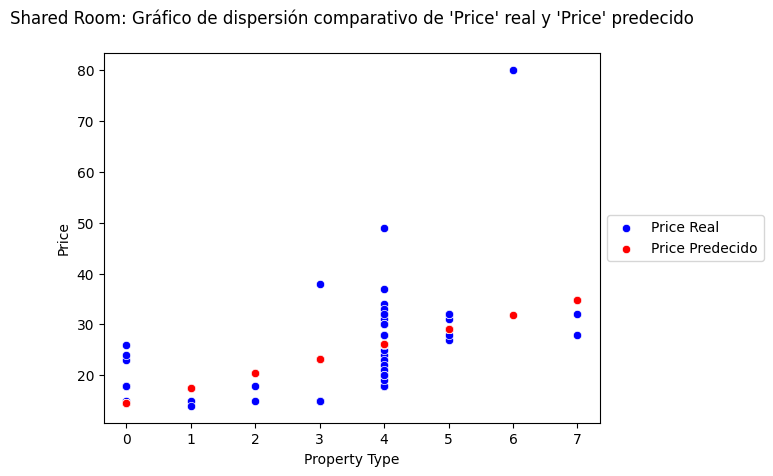

In [698]:
#Visualizamos la grafica comparativa entre el total real y el total predecido
sns.scatterplot(x='property_type_encoded', y='price', color="blue", data=Grecia_SR)
sns.scatterplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_SR)
#sns.lineplot(x='property_type_encoded', y='Predicciones_price_property_type', color="red", data=Grecia_SR)

# Configurar el título, etiquetas y leyenda
plt.title("Shared Room: Gráfico de dispersión comparativo de 'Price' real y 'Price' predecido\n")
plt.xlabel("Property Type")
plt.ylabel("Price")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()


In [699]:
#Corroboramos cual es el coeficiente de determinacion de nuestro modelo
coef_Deter = model.score(vars_Indep, var_Dep)
resultados[("Shared_room","price_property_type","determinacion")] = coef_Deter
coef_Deter

0.20049352339504622

In [700]:
#Corroboramos cual es el coeficiente de correlacion de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
resultados[("Shared_room","price_property_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.44776503145628316)

In [701]:
Grecia_SR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   last_scraped                                  55 non-null     object 
 1   source                                        55 non-null     object 
 2   name                                          55 non-null     object 
 3   description                                   55 non-null     object 
 4   neighborhood_overview                         55 non-null     object 
 5   host_name                                     55 non-null     object 
 6   host_since                                    55 non-null     object 
 7   host_location                                 55 non-null     object 
 8   host_about                                    55 non-null     object 
 9   host_response_time                            55 non-null     objec

# Tabla de coeficientes de determinación y correlación

In [702]:
filas = []
for (modelo, prediccion, tipo), valor in resultados.items():
    filas.append({"Modelo": modelo, "Predicción": prediccion, "Tipo": tipo, "Valor": valor})

# Crear DataFrame
df_res = pd.DataFrame(filas)

# Mostrar la tabla con formato pivotado
df_pivot = df_res.pivot(index=["Modelo", "Predicción"], columns="Tipo", values="Valor")
df_pivot

Tipo                                            correlacion  determinacion
Modelo         Predicción                                                 
Entire_homeapt bathrooms_accommodates              0.431789       0.186442
               price_host_acceptance_rate          0.061910       0.003833
               price_host_identity_verified        0.016078       0.000259
               price_host_is_superhost             0.117064       0.013704
               price_instant_bookable              0.070483       0.004968
               price_property_type                 0.055510       0.003081
               price_review_scores_cleanliness     0.155438       0.024161
Hotel_room     bathrooms_accommodates              0.548832       0.301217
               price_host_acceptance_rate          0.228732       0.052318
               price_host_identity_verified        0.000000       0.000000
               price_host_is_superhost             0.304569       0.092762
               price_instant_bookable              0.240711       0.057942
               price_property_type                 0.324378       0.105221
               price_review_scores_cleanliness     0.030838       0.000951
Private_room   bathrooms_accommodates              0.020941       0.000439
               price_host_acceptance_rate          0.016190       0.000262
               price_host_identity_verified        0.365076       0.133281
               price_host_is_superhost             0.018800       0.000353
               price_instant_bookable              0.235788       0.055596
               price_property_type                 0.366296       0.134172
               price_review_scores_cleanliness     0.294789       0.086900
Shared_room    bathrooms_accommodates              0.059947       0.003594
               price_host_acceptance_rate          0.441766       0.195157
               price_host_identity_verified        0.257716       0.066418
               price_host_is_superhost             0.099311       0.009863
               price_instant_bookable              0.194865       0.037972
               price_property_type                 0.447765       0.200494
               price_review_scores_cleanliness     0.172313       0.029692

In [703]:
def mostrarTabla():
    print(f"Tabla para la Predicción: {comparacion}")
    df_res_pivot

# Filtrar las comparaciones únicas (asumimos que tienes 7 comparaciones distintas)
comparaciones_unicas = df_res['Predicción'].unique()

# Crear las 7 tablas, una por cada Predicción
for comparacion in comparaciones_unicas:
    # Filtrar por la Predicción
    df_prediccion = df_res[df_res['Predicción'] == comparacion]
    
    # Pivotar la tabla para comparar los 4 datasets en cada tipo
    df_res_pivot = df_prediccion.pivot(index="Modelo", columns="Tipo", values="Valor")
    
    # Mostrar la tabla pivotada
    print(f"Tabla para la Predicción: {comparacion}")
    display(df_res_pivot)

Tabla para la Predicción: price_host_acceptance_rate


Tipo,correlacion,determinacion
Modelo,,
Entire_homeapt,0.061910,0.003833
Hotel_room,0.228732,0.052318
Private_room,0.016190,0.000262
Shared_room,0.441766,0.195157


Tabla para la Predicción: price_host_is_superhost


Tipo,correlacion,determinacion
Modelo,,
Entire_homeapt,0.117064,0.013704
Hotel_room,0.304569,0.092762
Private_room,0.018800,0.000353
Shared_room,0.099311,0.009863


Tabla para la Predicción: bathrooms_accommodates


...

Tipo,correlacion,determinacion
Modelo,,
Entire_homeapt,0.016078,0.000259
Hotel_room,0.000000,0.000000
Private_room,0.365076,0.133281
Shared_room,0.257716,0.066418


Tabla para la Predicción: price_instant_bookable


Tipo,correlacion,determinacion
Modelo,,
Entire_homeapt,0.070483,0.004968
Hotel_room,0.240711,0.057942
Private_room,0.235788,0.055596
Shared_room,0.194865,0.037972


Tabla para la Predicción: price_property_type


Tipo,correlacion,determinacion
Modelo,,
Entire_homeapt,0.055510,0.003081
Hotel_room,0.324378,0.105221
Private_room,0.366296,0.134172
Shared_room,0.447765,0.200494


In [704]:
# Obtener las filas con el mayor coeficiente de correlación y determinación por dataset
max_corr = df_pivot.groupby(level=0)['correlacion'].idxmax()
max_determ = df_pivot.groupby(level=0)['determinacion'].idxmax()

# Crear la tabla con los resultados
filas = []
for dataset, (modelo_corr, pred_corr) in max_corr.items():
    filas.append({"Dataset": dataset, "Métrica": "correlacion", "Modelo": modelo_corr, "Predicción": pred_corr, "Valor": df_pivot.loc[(modelo_corr, pred_corr), "correlacion"]})

for dataset, (modelo_determ, pred_determ) in max_determ.items():
    filas.append({"Dataset": dataset, "Métrica": "determinacion", "Modelo": modelo_determ, "Predicción": pred_determ, "Valor": df_pivot.loc[(modelo_determ, pred_determ), "determinacion"]})

# Convertir a DataFrame
best_metrics_df = pd.DataFrame(filas)

# Mostrar la tabla final con los 4 mejores valores (2 por cada dataset)
best_metrics_df

,Dataset,Métrica,Modelo,Predicción,Valor
0,Entire_homeapt,correlacion,Entire_homeapt,bathrooms_accommodates,0.431789
1,Hotel_room,correlacion,Hotel_room,bathrooms_accommodates,0.548832
2,Private_room,correlacion,Private_room,price_property_type,0.366296
3,Shared_room,correlacion,Shared_room,price_property_type,0.447765
4,Entire_homeapt,determinacion,Entire_homeapt,bathrooms_accommodates,0.186442
5,Hotel_room,determinacion,Hotel_room,bathrooms_accommodates,0.301217
6,Private_room,determinacion,Private_room,price_property_type,0.134172
7,Shared_room,determinacion,Shared_room,price_property_type,0.200494
